# Modelling, fitting, convolution

A particle physics experiment consists of a large tank of liquid scintillator- a material that emits visible photons when a high energy particle (from, say, radioactive decay) goes through it.  The tank is a cylinder, 6 m in diameter and 6 m high, covered with 24 cm diameter circular photosensitive detectors (PMTs) on both both top and bottom, as well as the cylindrical walls.

Define a coverage scheme where the photosensors are relatively close packed.  How many detectors are required?  Number them in an unambiguous way, and write two functions- one of which returns a PMT number given $\vec{r}$ on the surface of the detector, and one which returns $\vec{r}$ at the center of the PMT for a given PMT number.  

 The angular range filled by one pmt is 0.083 radians for  75.376 pmts in the outer ring
The number of pmts that can fit around the outer 24 cm ring is 75.0.
The radii of the pmt rings are
 [2.88 2.64 2.4  2.16 1.92 1.68 1.44 1.2  0.96 0.72 0.48 0.24]


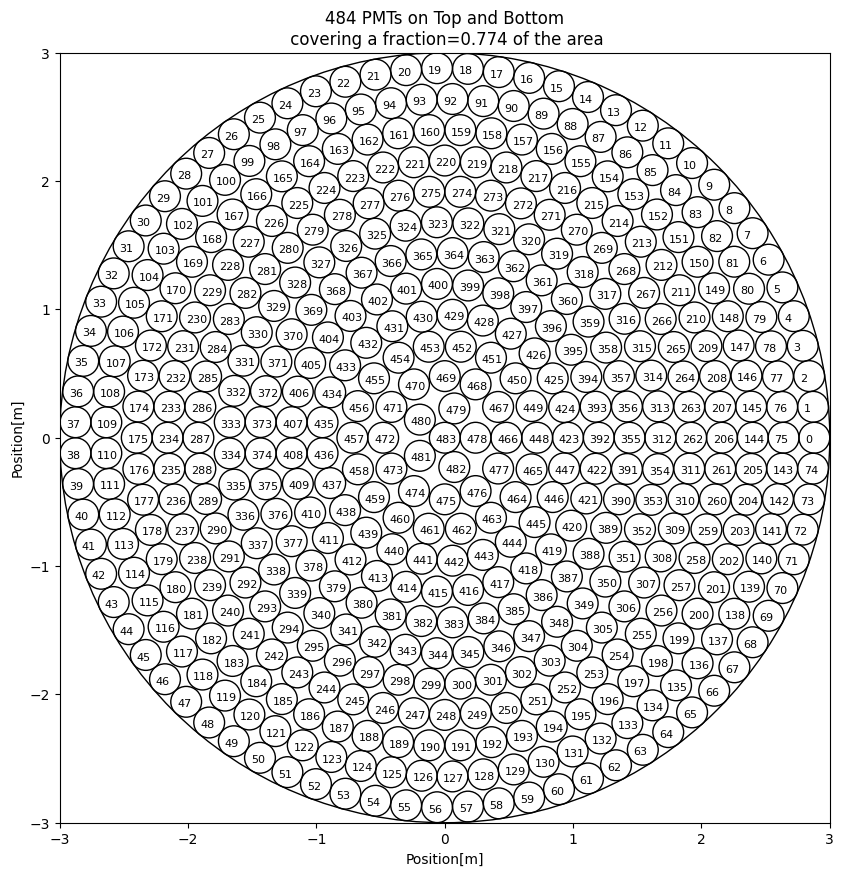

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.constants import c

#we will use units of meters for length, and ns for time.  
Rpmt=0.24/2 #m
RDisk=3 #m
cn=c/1.5*1e-9  #index of refraction of light is 1.5, time in ns, length in meters

angle=2*np.arcsin(Rpmt/(RDisk-Rpmt))
print(f' The angular range filled by one pmt is {angle:5.3f} radians for {2*np.pi/angle:7.3f} pmts in the outer ring')
n=np.floor(2*np.pi/angle)
print(f'The number of pmts that can fit around the outer 24 cm ring is {n}.')
p=[]  #list of PMT positions-- the front center of each phototube.
rlist=np.arange(RDisk-Rpmt,0,-2*Rpmt)  #list of ring radii.
print('The radii of the pmt rings are\n',rlist)
nstart=[] #the entry in p in which a ring starts
dtheta=[]
for r in rlist:
    angle=2*np.arcsin(Rpmt/(r))
    n=int(np.floor(2*np.pi/angle))
    theta=2*np.pi/n
    dtheta.append(theta)
    nstart.append(len(p))
    for i in range(n):
        p.append([r*np.cos(i*theta),r*np.sin(i*theta),-3.0])
#add pmt at the bottom
nstart.append(len(p))
p.append([0,0,-3])
nDisk=len(p)
p=np.array(p)

plt.rcParams['figure.figsize'] = [10,10]

figure, axes = plt.subplots()
 
axes.set_aspect( 1 )
axes.add_artist(plt.Circle((0.,0.),RDisk,fill=False ))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title( f'{len(p)} PMTs on Top and Bottom\n covering a fraction={len(p)*Rpmt**2/RDisk**2:5.3f} of the area' )
plt.xlabel('Position[m]')
plt.ylabel('Position[m]')
for i,a in enumerate(p):
    axes.add_artist(plt.Circle((a[0],a[1]),Rpmt,fill=False))
    plt.text(a[0]-.6*Rpmt,a[1]-Rpmt/3,f'{i}',fontsize=8)
plt.show()






In [5]:
nstart

[0, 75, 144, 206, 262, 312, 355, 392, 423, 448, 466, 478, 483]

Text(0, 0.5, 'position[m]')

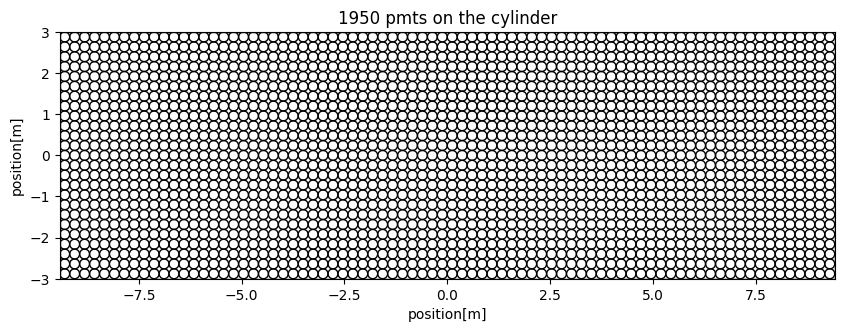

In [6]:
plt.rcParams['figure.figsize'] = [10,10]
figure, axes = plt.subplots()
 
axes.set_aspect( 1 )
axes.add_artist(plt.Rectangle((-np.pi*3,-3),np.pi*6,6,fill=False))
plt.xlim(-np.pi*3,np.pi*3)
plt.ylim(-3,3)
row=np.arange(-3+Rpmt,3+Rpmt,2*Rpmt)
ncols=int(3*np.pi/Rpmt)
dx=(6*np.pi)/ncols
dthet=dx/3
col=np.arange(-3*np.pi+Rpmt,3*np.pi+Rpmt,dx)
for x in col:
    for y in row:
        axes.add_artist(plt.Circle((x,y),Rpmt,fill=False))
plt.title(f'{len(row)*len(col)} pmts on the cylinder')
plt.xlabel("position[m]")
plt.ylabel('position[m]')

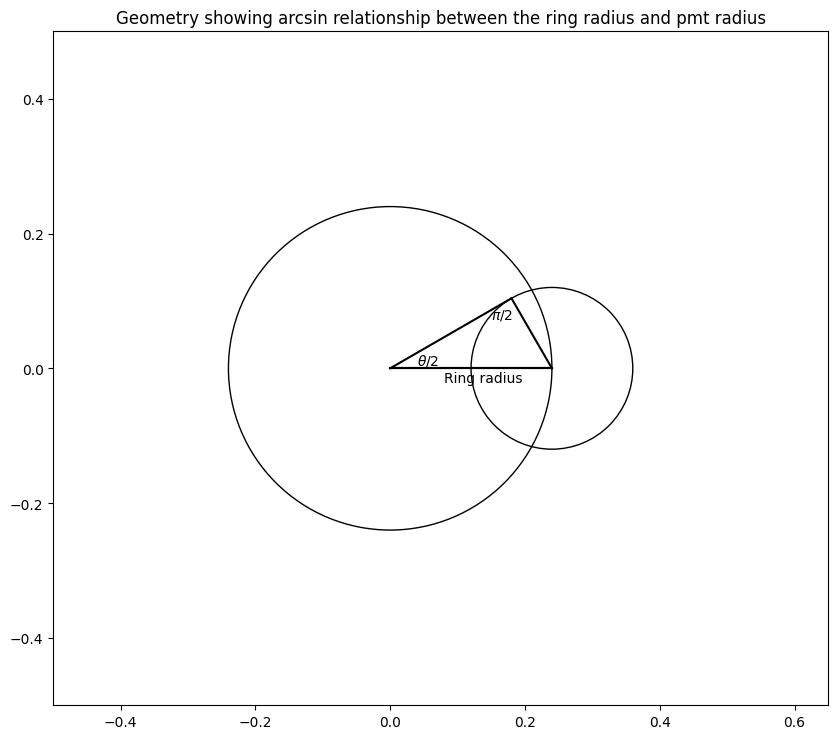

In [7]:
Rring=2*Rpmt
figure,axes=plt.subplots()
axes.set_aspect( 1 )
axes.add_artist(plt.Circle((0.,0.),Rring,fill=False ))
axes.add_artist(plt.Circle((Rring,0),Rpmt,fill=False))
plt.plot([0,Rring],[0,0],'k')
a=np.sqrt(Rring**2-Rpmt**2) # hypotenuse Rring, opposite side Rpmt
theta=np.arcsin(Rpmt/Rring)
plt.plot([0,Rring],[0,0],'k')
plt.plot([0,a*np.cos(theta)],[0,a*np.sin(theta)],'k')
plt.plot([Rring,a*np.cos(theta)],[0,a*np.sin(theta)],'k')
plt.text(a*np.cos(theta)-0.03,a*np.sin(theta)-0.03,r'$\pi/2$')
plt.text(0.04,0.005,r'$\theta/2$')
plt.text(Rring/2-0.04,-0.02,'Ring radius')
plt.xlim(-0.5,0.65)
plt.ylim(-0.5,0.5)
plt.title("Geometry showing arcsin relationship between the ring radius and pmt radius")
plt.show()

In [14]:
def pmtCenter(ipmt):
    if ipmt<nDisk:  #bottom
        pmt=p[ipmt]
    elif ipmt<2*nDisk: #top
        pmt=np.copy(p[ipmt-nDisk])
        pmt[2]=3
    else:
        ix=(ipmt-2*nDisk)%ncols
        iy=(ipmt-2*nDisk)//ncols
        theta=ix*dthet
        pmt=np.array([3*np.cos(theta),3*np.sin(theta),(iy*2+1)*Rpmt-3])
    return(pmt)

In [37]:
def pmtNumber(r):
#    print(r)
    if np.abs(r[2]-3) < 1e-6 or np.abs(r[2]+3) <1e-6:  #top or bottom
#        print("top or bottom")
        radius=np.linalg.norm(r[0:2])
#        print(r,radius)
        n=len(nstart)-int(radius/2/Rpmt+0.5)-1
#        print('n=',n)
        if n==len(nstart)-1:
            pmt=nstart[-1]
#            print('n=len',pmt)
        else:
            theta=np.arctan2(r[1],r[0])+0.5*dtheta[n]
#            print('theta=',theta)
            if theta<0:
                theta=np.pi*2+theta
            npmt=int(theta/dtheta[n])
#            print('npmt=',npmt)
            pmt=nstart[n]+npmt
#            print(pmt)
#            print('abs r2',np.abs(r[2]-3))
        if np.abs(r[2]-3) <1e-6:
            pmt=pmt+nDisk
#            print(pmt)
    elif np.abs(np.linalg.norm(r[0:2])-3) <1e-6: #cylinder
        theta=np.arctan2(r[1],r[0])+0.5*dthet
        if theta<0:
            theta=2*np.pi+theta
#        print('theta=',theta)
        npmt=int(theta/dthet)
        nrow=int((r[2]+3)/2/Rpmt)
#        print(f'{theta/dtheta} npmt={npmt}, nrow={nrow}, len(col)={len(col)}, dx={dx}')
        pmt=npmt+nrow*len(col)+2*nDisk
    return int(pmt)


In [38]:
#test if pmtNumber inverts pmtCenter
for i in range(0,2*nDisk+1950):
    if i%100==0:
        print('i=',i)
    if pmtNumber(pmtCenter(i))!= i:
        print(i)

i= 0
i= 100
i= 200
i= 300
i= 400
i= 500
i= 600
i= 700
i= 800
i= 900
i= 1000
i= 1100
i= 1200
i= 1300
i= 1400
i= 1500
i= 1600
i= 1700
i= 1800
i= 1900
i= 2000
i= 2100
i= 2200
i= 2300
i= 2400
i= 2500
i= 2600
i= 2700
i= 2800
i= 2900


In [39]:
#test if pmtNumber inverts pmtCenter when we are offset in x
for i in range(0,2*nDisk+1950):
    if i%100==0:
        print('i=',i)
    if i<2*nDisk:
        delta=np.array([0.999*Rpmt,0,0])
    else:
        delta=np.array([0,0,0.99*Rpmt])
    if pmtNumber(pmtCenter(i)-delta)!= i:
        print(i)

i= 0
i= 100
i= 200
i= 300
i= 400
i= 500
i= 600
i= 700
i= 800
i= 900
i= 1000
i= 1100
i= 1200
i= 1300
i= 1400
i= 1500
i= 1600
i= 1700
i= 1800
i= 1900
i= 2000
i= 2100
i= 2200
i= 2300
i= 2400
i= 2500
i= 2600
i= 2700
i= 2800
i= 2900


In [18]:
delta=np.array([0.999*Rpmt,0,0])
pmtNumber(pmtCenter(484))
pmtCenter(484)

array([2.88, 0.  , 3.  ])

In [40]:
#test if pmtNumber inverts pmtCenter when offset in y
for i in range(0,968+1950):
    if i%100==0:
        print('i=',i)
    if i<968:
        delta=np.array([0,0.99*Rpmt,0])
        if pmtNumber(pmtCenter(i))!= i:
            print(i)
    else:
        delta=pmtCenter(i)/3
        delta[2]=0
        x=delta[0]
        delta[0]=-delta[1]
        delta[1]=x
        delta=delta*Rpmt*0.99
        rot=pmtCenter(i)-delta
        rot[:2]=3*rot[:2]/np.linalg.norm(rot[:2])
        if pmtNumber(rot)!= i:
            print(i,rot,r)
#        print(pmtCenter(i),delta,pmtCenter(i)-delta)

print(pmtCenter(968))
pmtNumber(pmtCenter(968))

i= 0
i= 100
i= 200
i= 300
i= 400
i= 500
i= 600
i= 700
i= 800
i= 900
i= 1000
i= 1100
i= 1200
i= 1300
i= 1400
i= 1500
i= 1600
i= 1700
i= 1800
i= 1900
i= 2000
i= 2100
i= 2200
i= 2300
i= 2400
i= 2500
i= 2600
i= 2700
i= 2800
i= 2900
[ 3.    0.   -2.88]


968

# 33

Throw 100000 $\cos\theta$'s from -1 to 1 and throw $\phi$ from 0 to 2$\pi$.  Then histogram $\sin\theta \cos \phi, \sin\theta\sin\phi, \cos\theta$. Is there any difference between the three histograms?



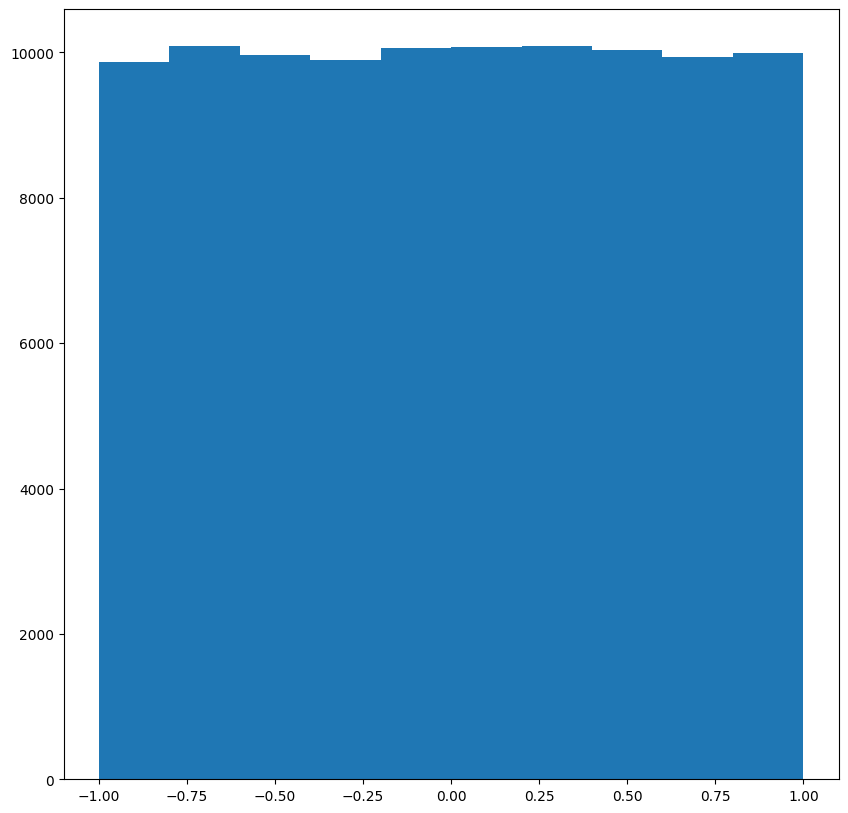

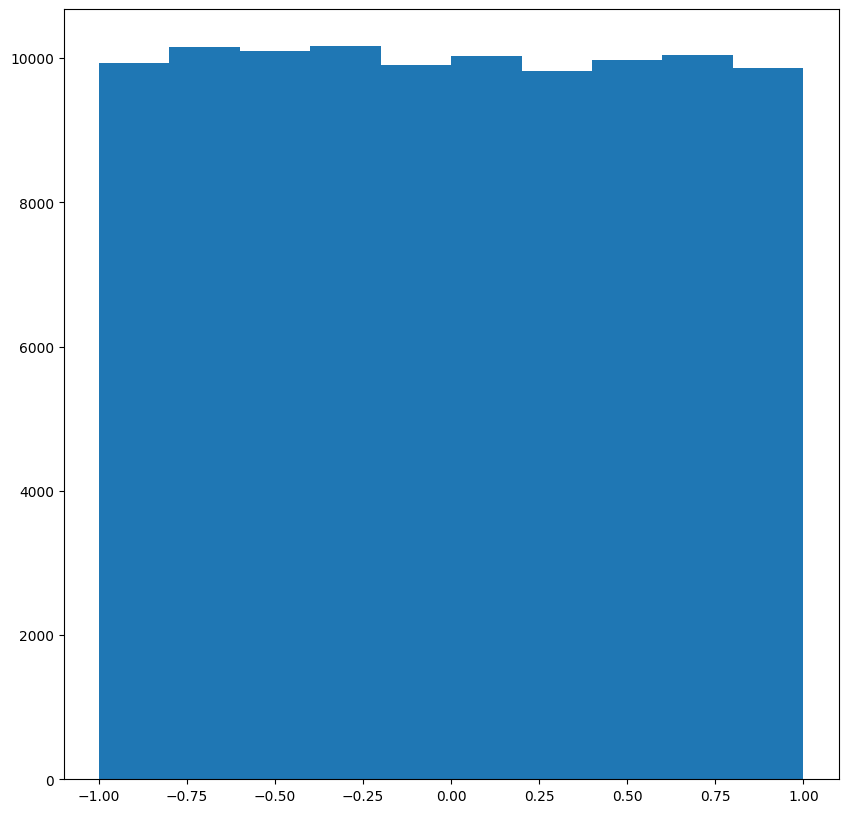

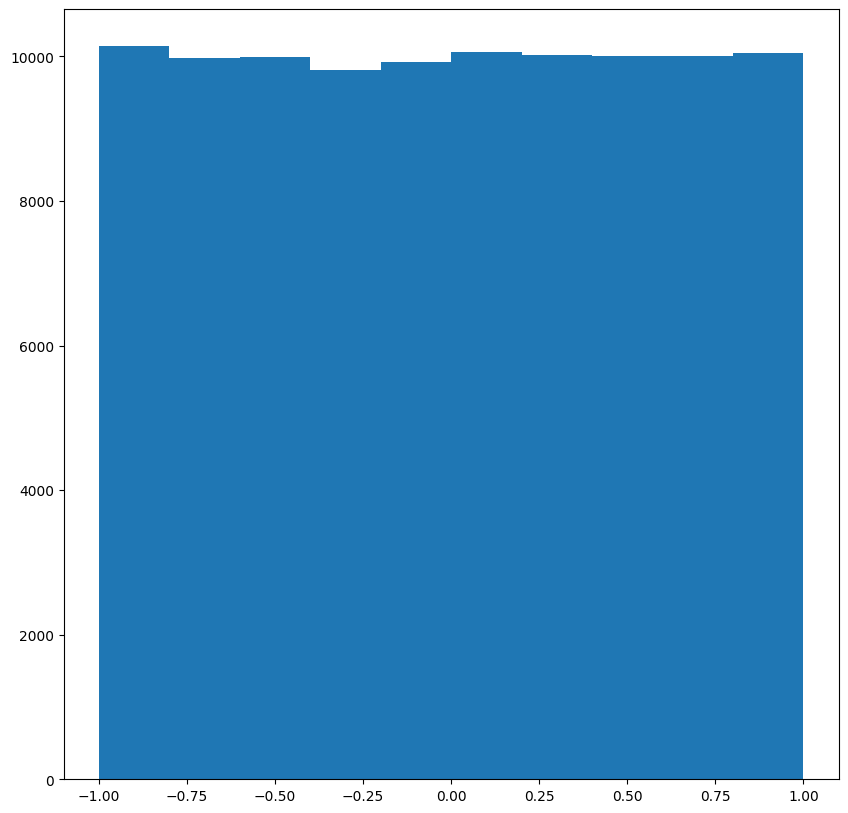

(array([ 9888.,  9872., 10071.,  9991.,  9980., 10094.,  9968., 10141.,
         9971., 10024.]),
 array([-9.99998449e-01, -7.99998604e-01, -5.99998759e-01, -3.99998914e-01,
        -1.99999069e-01,  7.75679632e-07,  2.00000621e-01,  4.00000465e-01,
         6.00000310e-01,  8.00000155e-01,  1.00000000e+00]),
 <BarContainer object of 10 artists>)

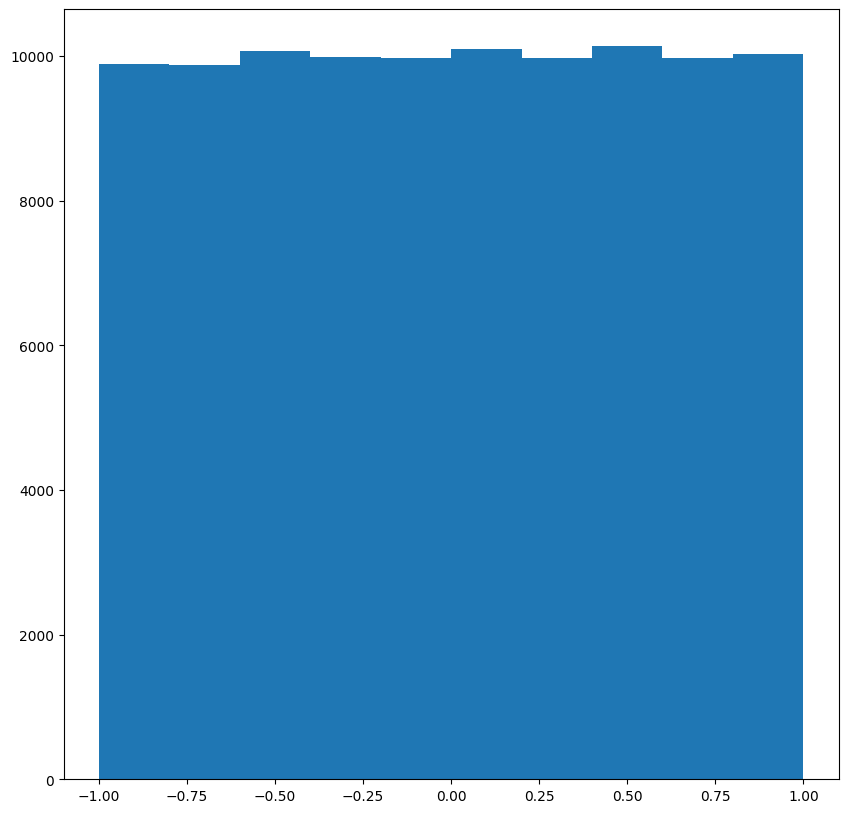

In [41]:






















rng=np.random.default_rng()
ct=rng.uniform(-1,1,100000)
phi=rng.uniform(0,2*np.pi,100000)
st=np.sqrt(1-ct*ct)
plt.hist(st*np.cos(phi))
plt.show()
plt.hist(st*np.sin(phi))
plt.show()
plt.hist(ct)
plt.show()

v=np.array([st*np.cos(phi),st*np.sin(phi),ct]).transpose()
vtest=v[12345]
plt.hist(np.dot(v,vtest))



# Modelling scintillation light
Scintillation light is produced when certain materials are ionized by particles emitted in radioactive decay or from nuclear interactions.  Theoretical initial light yields might be up to 10000 photons/MeV, but realities of liquid scintillator behaviour, absorption/re-emission and pmt efficiences mean that more realistic numbers are more like 2000 photons/MeV.  

We start by generating 2000 photons isotropically from a random point in the detector.  
How do we pick a random point?  We can simply generate a z-value with a random number generator, and a $\rho$ value setting the probability equal to the area:  
$$P(\rho<\rho_0)=\frac{\int_0^{\rho_0} 2\pi \rho d\rho}{\pi R^2}   =\frac {\rho^2}{R^2}$$

so $\rho=R\sqrt{U},$ where $U$ is a random number generated uniformly between 0 and 1.  We can generate $\phi$ uniformly from 0 to $2\pi.$

We will now pick a random point in the detector, and label it $\vec{v}$ for vertex.

In [43]:
rng=np.random.default_rng()
z=(rng.random()-0.5)*6  #from -3 to 3
rho=3*np.sqrt(rng.random())
phi=2*rng.random()*np.pi
v=np.array([rho*np.cos(phi),rho*np.sin(phi), z])
print(v)

[-0.23146599  1.12386591  1.72320825]


The next step will be to generate our 2000 photons.  Here we will need to generate a direction and a time. We will assume the scintillator generates 80% of its photons with a 5 ns decay time, and 20% with a 100 ns decay time. We will also impose a 0.8 ns rise time; we can do this by assuming that there is a state with a 0.8ns decay time that generates the photons.  All these times are "livetimes"-- ie. 1/e times rather than half lives.

We generate the 2000 photons and plot their time.  

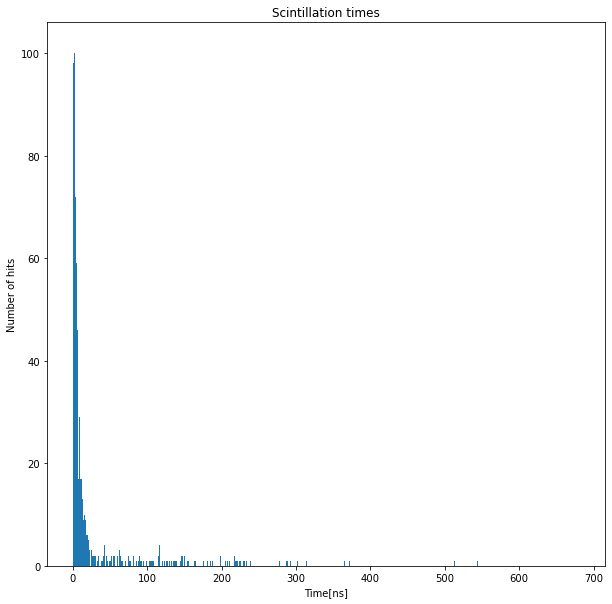

[ 55.  91.  98. 101. 101. 100.  93.  85.  72.  71.]


In [421]:
N=2000 #try at 2M
trise=rng.exponential(0.8,N)
tfast=rng.exponential(5,N)
tslow=rng.exponential(100,N)
select=rng.random(N)
tdecay=trise+np.where(select<0.8,tfast,tslow)
hist=plt.hist(tdecay,1500)[0]
plt.title('Scintillation times')
plt.xlabel('Time[ns]')
plt.ylabel('Number of hits')
#plt.yscale('log')
plt.show()
print(hist[:10])

Now let's generate 2000 random directions.  For this, we generate $\cos\theta$ flat, and $\phi$ flat.

In [422]:
costheta=rng.random(2000)*2-1
phi=rng.random(2000)*np.pi*2
sintheta=np.sqrt(1.0-costheta**2)
directions=np.vstack([sintheta*np.cos(phi),sintheta*np.sin(phi),costheta])

In [423]:
print(directions)

[[ 0.93252552 -0.00470429 -0.32508617 ... -0.26192071 -0.97211884
  -0.96666741]
 [ 0.30572907  0.26466664 -0.31484433 ... -0.95322155 -0.2307141
   0.18795256]
 [-0.19216109 -0.96432849  0.8917354  ... -0.15088478  0.0419043
   0.17386188]]


In [424]:
print(directions.transpose())

[[ 0.93252552  0.30572907 -0.19216109]
 [-0.00470429  0.26466664 -0.96432849]
 [-0.32508617 -0.31484433  0.8917354 ]
 ...
 [-0.26192071 -0.95322155 -0.15088478]
 [-0.97211884 -0.2307141   0.0419043 ]
 [-0.96666741  0.18795256  0.17386188]]


The equation of the top plane is z=3 m or $\vec{x}\cdot \hat{k}=3$, and so the solution for our line is $(\vec{v}+d\hat{n})\cdot\hat{k}=3$,
or $v_z+d n_z=3\rightarrow d=\frac{3-v_z}{n_z}$. For the barrel, we have   $\rho(\vec{v}+d\hat{n})=R$, where $\rho^2=x^2+y^2,$ the cylindrical radius. 

In [425]:
#calculate distances=time*speed of light to top, bottom, and barrel for each pmt
dtop=(3-v[2])/directions[2]
dbottom=(-3-v[2])/directions[2]
radius=3.0
#for barrel (v+d*direction)**2=R**2->v**2+2*d*direction*v +d**2=R**2
for dir in directions.transpose()[:10]:
    poly=np.polynomial.Polynomial([np.dot(v[:2],v[:2])-RDisk**2,2*np.dot(dir[:2],v[:2]),np.dot(dir[:2],dir[:2])])
    dbarrel=poly.roots()
#validation
    print('radius when track intersects of barrel',np.linalg.norm((v+dbarrel[1]*dir)[0:2]))
    
dbarrel=[np.polynomial.Polynomial([np.dot(v[:2],v[:2])-RDisk**2,2*np.dot(dir[:2],v[:2]),np.dot(dir[:2],dir[:2])]).roots()
         [1] for dir in directions.transpose()]
print('dtop=',dtop[:10],'\n dbottom=',dbottom[:10],'\n dbarrel=',dbarrel[:10])

radius when track intersects of barrel 3.0
radius when track intersects of barrel 2.9999999999999996
radius when track intersects of barrel 3.0
radius when track intersects of barrel 3.0000000000000004
radius when track intersects of barrel 3.0000000000000004
radius when track intersects of barrel 3.0
radius when track intersects of barrel 2.9999999999999996
radius when track intersects of barrel 2.9999999999999996
radius when track intersects of barrel 3.0000000000000004
radius when track intersects of barrel 3.0000000000000004
dtop= [-10.92345576  -2.17670973   2.35390812   2.42117788  -2.14027675
  10.13795817   4.02502052  10.12771158  -5.6334179    3.47603393] 
 dbottom= [ 20.30034656   4.04523649  -4.37454517  -4.49956051   3.97752878
 -18.84056372  -7.4801705  -18.82152127  10.46924509  -6.45992394] 
 dbarrel= [1.4143015378672819, 7.587908534927794, 9.809722771869943, 2.967685508796628, 18.430672966177177, 3.0481385028272157, 4.00361413778039, 1.778763444908373, 4.50174628484308

Now we have 4 intersections for each photon-- one on the top, one on the bottom and two on the barrel walls.  2 of them will always be negative and two will be positive.  We want to pick the smallest positive solution.  Since we are inside the barrel, we don't need to check if the top or bottom solutions have radius less than 3, or that the barrel solutions have z between -3 and 3, since the smallest solution will always satisfy that condition.  If we were making an intersection for a photon that started outside the detector, we would.  

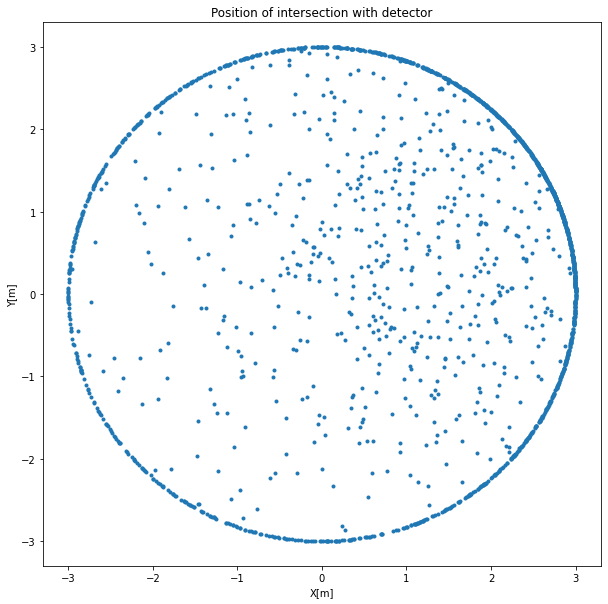

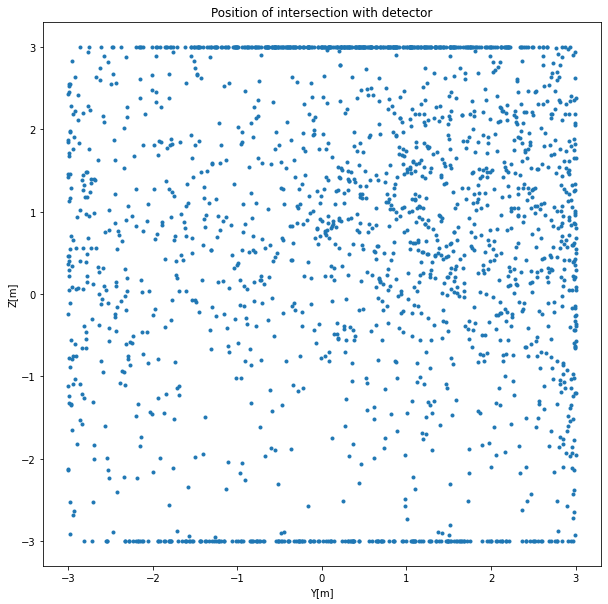

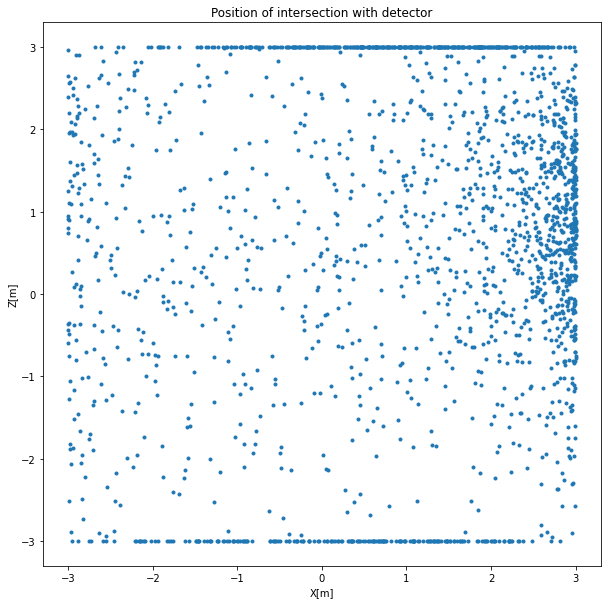

In [426]:
dtop[np.asarray(dtop<0).nonzero()]=np.infty  #because we want to never pick a negative time.  
dbottom[np.asarray(dbottom<0).nonzero()]=np.infty
dlist=np.array([dtop,dbottom,dbarrel])
d=np.min(dlist,axis=0)
positions=(d*directions).transpose()+v
plt.plot(positions[:,0],positions[:,1],'.')
plt.title("Position of intersection with detector")
plt.xlabel('X[m]')
plt.ylabel('Y[m]')
plt.show()
plt.plot(positions[:,1],positions[:,2],'.')
plt.title("Position of intersection with detector")
plt.xlabel('Y[m]')
plt.ylabel('Z[m]')
plt.show()
plt.plot(positions[:,0],positions[:,2],'.')
plt.title("Position of intersection with detector")
plt.xlabel('X[m]')
plt.ylabel('Z[m]')
plt.show()

In [427]:
v

array([1.49265076, 0.61419098, 0.9009368 ])

Now we assume that the PMTs are 30% efficient--- ie. 30% of pulses result in data.  

In [428]:

pmtList=[]
for ev in zip(positions,tdecay):
    r,t0=ev
    pmtN=pmtNumber(r)
    if np.linalg.norm(r-pmtCenter(pmtN))<Rpmt:  #only keep hits that happen inside diameter of PMT
        time=t0+np.linalg.norm(r-v)/cn
        pmtList.append((pmtN,time))
print(f'The fraction of surface covered by PMTs is {len(pmtList)/2000}.')

#repeat, keeping only 30% of the pulses
pmtList=[]
rand3=rng.random(2000)
for ev in zip(positions,tdecay,rand3):
    r,t0,r3=ev
    pmtN=pmtNumber(r)
    if np.linalg.norm(r-pmtCenter(pmtN))<Rpmt and r3<0.3:  #PMT border and efficiency tested
        time=t0+np.linalg.norm(r-v)/cn
        pmtList.append((pmtN,time))
print(f'The efficiency- defined by hit PMTs/all Photons is {len(pmtList)/2000}.')
pmtList=np.array(pmtList)

The fraction of surface covered by PMTs is 0.7845.
The efficiency- defined by hit PMTs/all Photons is 0.226.


# 34
Where does the light ray that start from a point (1,2,3) and travels in the direction parallel to (4,5,6) intersect the sphere of radius 10?



In [13]:























import numpy as np
x0=np.array([1,2,3])
n=np.array([4,5,6])
n=n/np.linalg.norm(n)
#(x0+dn)**2=r**2-> x0**2+2d n*x0+d**2=R**2
from numpy.polynomial import Polynomial as P
a=P([np.dot(x0,x0)-100,2*np.dot(n,x0),1])
d1=a.roots()[1]
inter=x0+d1*n
inter

array([3.88007319, 5.60009149, 7.32010979])

# How often are PMT's hit and when

We can now histogram and see when and where PMT's are hit.  

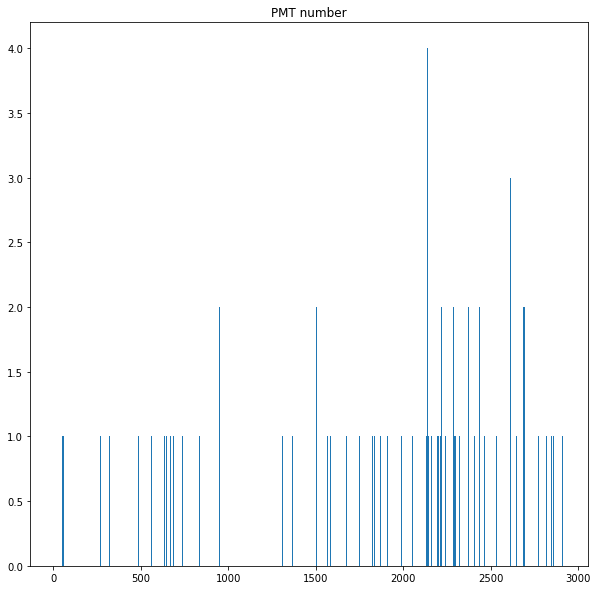

In [429]:
hPMT,a,b=plt.hist(pmtList[:,0],3000)
plt.title("PMT number")
plt.show()

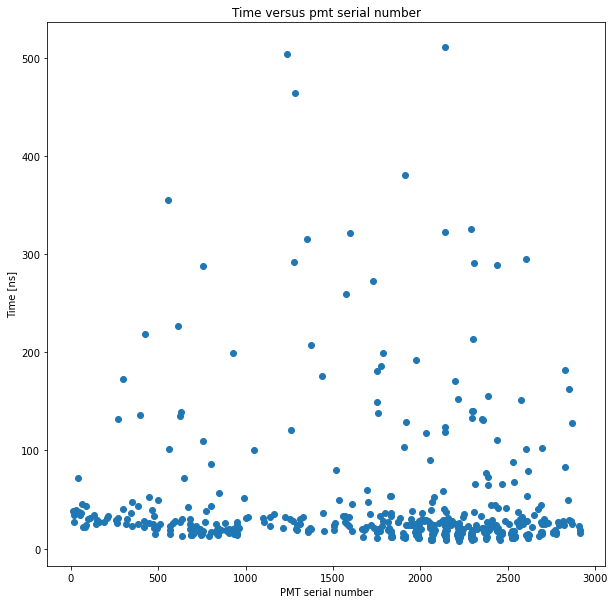

In [430]:
plt.scatter(pmtList[:,0],pmtList[:,1])
plt.xlabel("PMT serial number")
plt.ylabel("Time [ns]")
plt.title("Time versus pmt serial number")
plt.show()

## Reconstruction

Given an event- basically the list of hit PMT's along with the time of the hit, we want to *reconstruct* the position (and possibly energy) of the event.  

We do this by fitting the data to a model.  For our first reconstruction, we will just use the time at which light arrived at the PMT, and use a $\chi^2$ fit to minimize the time and position of the event.  We will get a more complex fitting procedure later; but to make this one work we will need to go back and tweak our event model-- so we only have a single fast scintillator decay time.  

We start by pulling all our event generation code into a single function, called event, and tweaking the time generation steps.

In [431]:
def event(N):
    #generate N photons
    rng=np.random.default_rng()
    z=(rng.random()-0.5)*6  #from -3 to 3
    rho=3*np.sqrt(rng.random())
    phi=2*rng.random()*np.pi
    v=np.array([rho*np.cos(phi),rho*np.sin(phi), z])
    t0=rng.random()*100  #generate a start time from 0-100 ns
    print('t0,v=',t0,v)
    
    #time generation
    trise=rng.exponential(0.8,N)
    tfast=rng.exponential(1,N)
    tdecay=t0+trise+tfast

    #generate directions
    costheta=rng.random(N)*2-1
    phi=rng.random(N)*np.pi*2
    sintheta=np.sqrt(1.0-costheta**2)
    directions=np.vstack([sintheta*np.cos(phi),sintheta*np.sin(phi),costheta])
    
    #calculate distances=time*speed of light to top, bottom, and barrel for each pmt
    dtop=(3-v[2])/directions[2]
    dbottom=(-3-v[2])/directions[2]
    radius=3
    dbarrel=[np.polynomial.Polynomial([np.dot(v[:2],v[:2])-RDisk**2,2*np.dot(dir[:2],v[:2]),np.dot(dir[:2],dir[:2])]).roots()
         [1] for dir in directions.transpose()]
    dtop[np.asarray(dtop<0).nonzero()]=np.infty
    dbottom[np.asarray(dbottom<0).nonzero()]=np.infty
    dlist=np.array([dtop,dbottom,dbarrel])
    d=np.min(dlist,axis=0)
    positions=(d*directions).transpose()+v
    
    pmtList=[]
    rand3=rng.random(N)
    for ev in zip(positions,tdecay,rand3):
        r,t0,r3=ev
        pmtN=pmtNumber(r)
        if np.linalg.norm(r-pmtCenter(pmtN))<Rpmt and r3<0.3:  #PMT border and efficiency tested
            time=t0+np.linalg.norm(r-v)/cn
            pmtList.append((pmtN,time))
    pmtList=np.array(pmtList)
    return(pmtList,t0,v)


Now we write a function to vary the event position $\vec{x}$ and the emission time $t$ to minimize $\chi^2=\sum_{i=0}^N \left(\frac{\vec{p}_i-\vec{x}}{c_n}-(t_i-t)\right)^2$

In [432]:
from scipy.optimize import minimize
sigmat=1.5
def chisquare(xarg,pmtList):
    t=xarg[0]
    x=xarg[1:4]
#    print('t,x=',t,x)
    p=np.array([pmtCenter(int(i)) for i in pmtList[:,0]])
    pnorm=(np.linalg.norm(p-x,axis=1)/cn+t-pmtList[:,1])/sigmat
#    print(pnorm.shape,pmtList[:,1].shape)    
    return np.sum(pnorm**2)
    

pL,t0,v=event(2000)
sol=minimize(chisquare,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
    

t0,v= 80.12534059582964 [0.26582647 1.95072965 2.68861242]


In [433]:
sol


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 325.62800299644266
        x: [ 8.187e+01  2.667e-01  1.974e+00  2.676e+00]
      nit: 18
      jac: [-5.628e-04  5.321e-03  5.650e-03 -6.833e-03]
     nfev: 120
     njev: 24
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

MC true time, position: 83.30254624519775 [0.26582647 1.95072965 2.68861242]  fit time and position: [81.87469909  0.26668334  1.97378199  2.67577955]


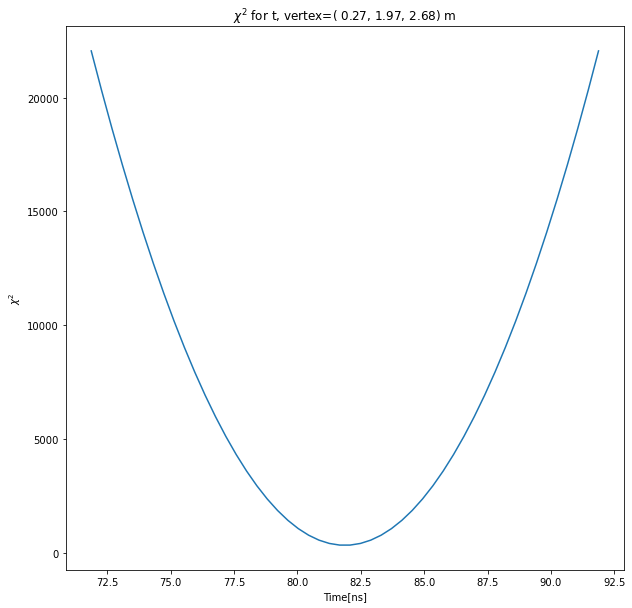

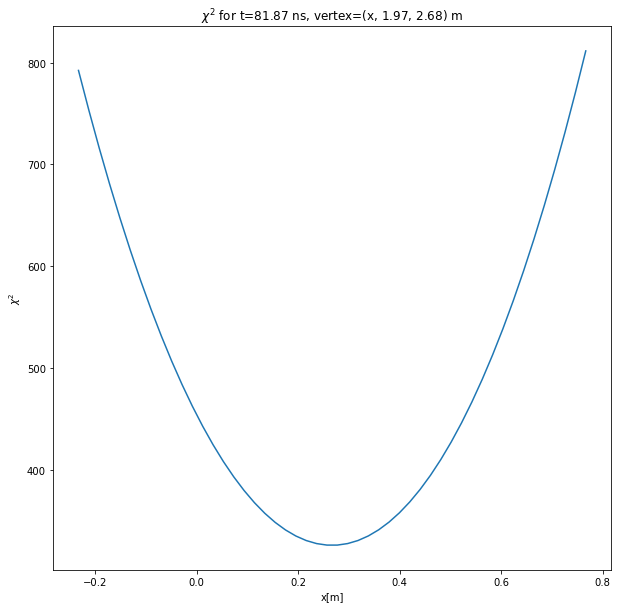

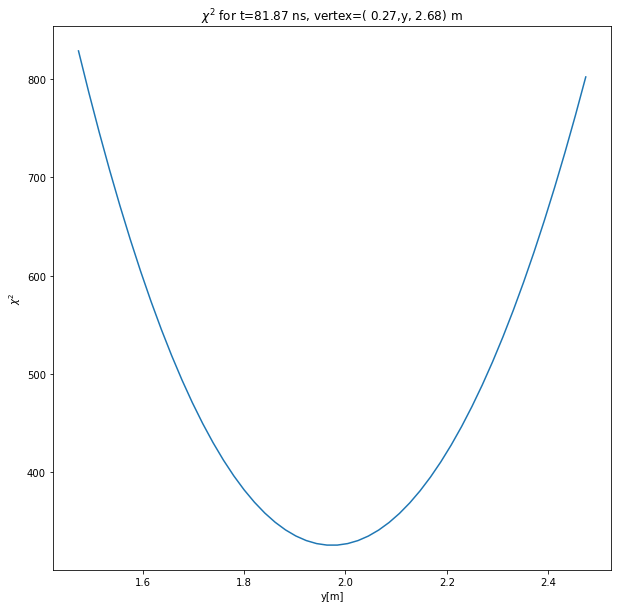

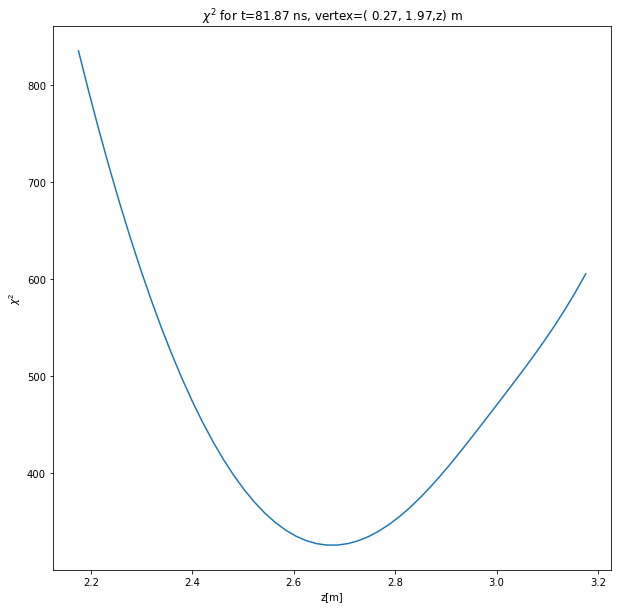

In [434]:
#now plot chisquare around the fit value...
print('MC true time, position:', t0,v, ' fit time and position:',sol.x)
tlist=np.linspace(sol.x[0]-10,sol.x[0]+10)
chilist=[chisquare(np.array([t,sol.x[1],sol.x[2],sol.x[3]]),pL) for t in tlist]
plt.plot(tlist,chilist)
plt.title(f'$\chi^2$ for t, vertex=({sol.x[1]:5.2f},{sol.x[2]:5.2f},{sol.x[3]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(sol.x[1]-.5,sol.x[1]+0.5)
chilist=[chisquare(np.array([sol.x[0],x,sol.x[2],sol.x[3]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={sol.x[0]:5.2f} ns, vertex=(x,{sol.x[2]:5.2f},{sol.x[3]:5.2f}) m')
plt.xlabel("x[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(sol.x[2]-.5,sol.x[2]+0.5)
chilist=[chisquare(np.array([sol.x[0],sol.x[1],x,sol.x[3]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={sol.x[0]:5.2f} ns, vertex=({sol.x[1]:5.2f},y,{sol.x[3]:5.2f}) m')
plt.xlabel("y[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(sol.x[3]-.5,sol.x[3]+0.5)
chilist=[chisquare(np.array([sol.x[0],sol.x[1],sol.x[2],x]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={sol.x[0]:5.2f} ns, vertex=({sol.x[1]:5.2f},{sol.x[2]:5.2f},z) m')
plt.xlabel("z[m]")
plt.ylabel("$\chi^2$")
plt.show()




# Bias
We can compare this to the fit if we put in the correct position that was used to model the event.  We don't get the right position back.  Why?  

True time and position of event is  83.30254624519775 [0.26582647 1.95072965 2.68861242]


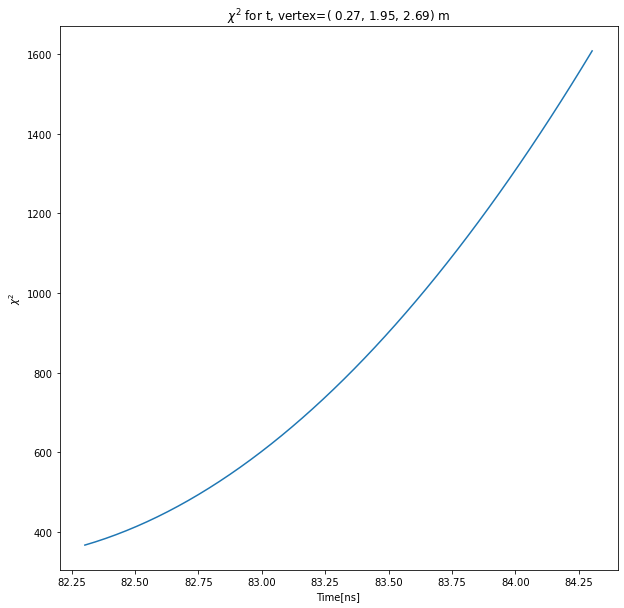

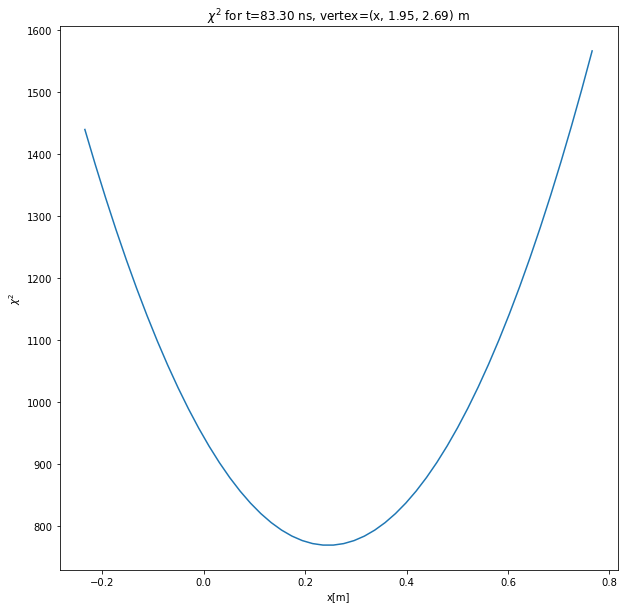

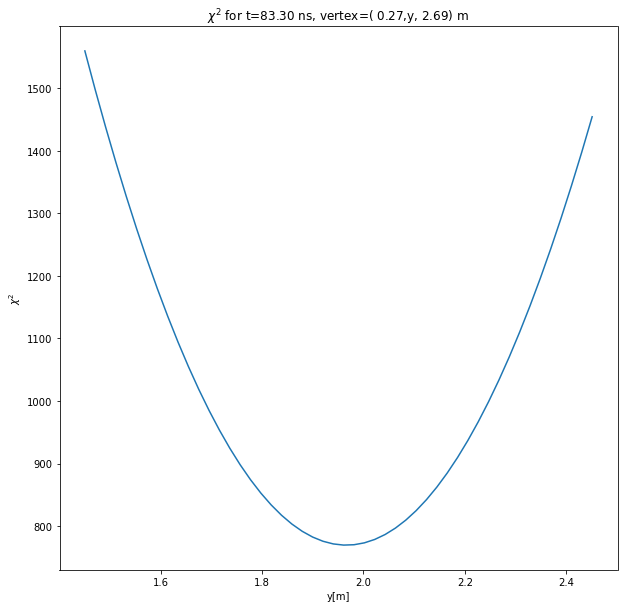

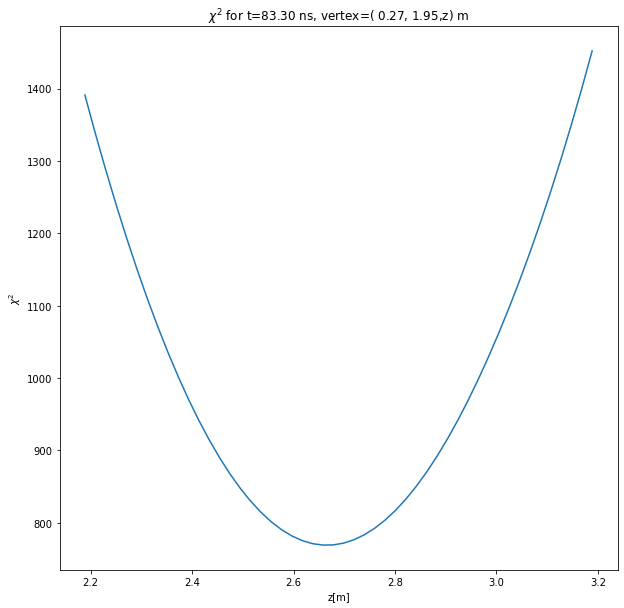

Minimum chisquare is 7.7e+02 for489 degrees of freedom.


In [435]:

print('True time and position of event is ', t0,v)
tlist=np.linspace(t0-1,t0+1)
chilist=[chisquare(np.array([t,v[0],v[1],v[2]]),pL) for t in tlist]
plt.plot(tlist,chilist)
plt.title(f'$\chi^2$ for t, vertex=({v[0]:5.2f},{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[0]-.5,v[0]+0.5)
chilist=[chisquare(np.array([t0,x,v[1],v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=(x,{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("x[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[1]-.5,v[1]+0.5)
chilist=[chisquare(np.array([t0,v[0],x,v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},y,{v[2]:5.2f}) m')
plt.xlabel("y[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[2]-.5,v[2]+0.5)
chilist=[chisquare(np.array([t0,v[0],v[1],x]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},{v[1]:5.2f},z) m')
plt.xlabel("z[m]")
plt.ylabel("$\chi^2$")
plt.show()

print(f'Minimum chisquare is {np.min(chilist):5.2} for{len(pL)} degrees of freedom.')


In [436]:
from scipy.stats import chi2
#chi2.cdf gives us the probability for a proper chi2 distribution
print(f'The chi2 probability of 360 for 465 dof is {chi2.cdf(360,465)}.')

The chi2 probability of 360 for 465 dof is 9.939236693108756e-05.


Repeat for a reasonable number of events, getting the reconstructed position for each one.  

In [437]:
events=[]
for i in range(1,100):
    pL,t0,v=event(2000)
    sol=minimize(chisquare,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
    events.append((pL,t0,v,sol.x,sol.fun,pL.shape[0]))

t0,v= 95.55597610398246 [1.34472847 0.92646179 0.75384965]
t0,v= 75.96510080202921 [-0.35053585 -2.34875575 -2.02760046]
t0,v= 51.41360471945592 [0.33386957 2.04532558 0.33564084]
t0,v= 94.47560189882483 [-0.73400532 -0.43542299  2.05021093]
t0,v= 82.05201281891765 [ 0.96358338  0.41074562 -1.16241868]
t0,v= 6.168108860815458 [-0.12894305  2.32607017 -0.41932392]
t0,v= 17.122165208803374 [-2.51116951 -0.20201155 -2.86621236]
t0,v= 45.37791689536274 [-1.35885458  0.90340633 -2.92203703]
t0,v= 48.007989068375664 [-1.16858031  0.78515698  0.73858835]
t0,v= 19.06600711677634 [-1.41582027  2.29778547 -0.39473549]
t0,v= 94.06990671963355 [ 2.15334391 -0.08327173 -1.24272747]
t0,v= 44.891109961946896 [ 0.45843441 -1.09491795  1.43405306]
t0,v= 73.32003327062473 [ 0.3594008  -1.08952481  1.86035018]
t0,v= 72.60036193846466 [-2.78103586 -0.60381982  0.07971739]
t0,v= 83.41763114142124 [-1.95451609  2.07419742 -2.50158531]
t0,v= 78.83877958300836 [ 0.32493348 -2.82270086 -0.03413263]
t0,v= 24.93

In [389]:
events[0]

(array([[2672.        ,   48.68931972],
        [2363.        ,   49.27292519],
        [2672.        ,   48.0097646 ],
        [ 345.        ,   68.34696252],
        [2519.        ,   46.01465047],
        [2461.        ,   66.68156688],
        [2408.        ,   71.3912941 ],
        [2518.        ,   48.34679446],
        [ 689.        ,   55.29411658],
        [2814.        ,   59.12549677],
        [ 834.        ,   49.90925873],
        [2680.        ,   52.86029197],
        [2439.        ,   48.30807177],
        [2439.        ,   45.00722048],
        [2105.        ,   67.00041665],
        [2601.        ,   51.64543219],
        [2539.        ,   66.91911265],
        [2675.        ,   47.22765865],
        [2750.        ,   45.94640406],
        [2596.        ,   50.4215226 ],
        [ 686.        ,   52.65917785],
        [ 791.        ,   50.75441921],
        [2673.        ,   45.55519788],
        [1452.        ,   73.30728604],
        [1319.        ,   74.07598053],


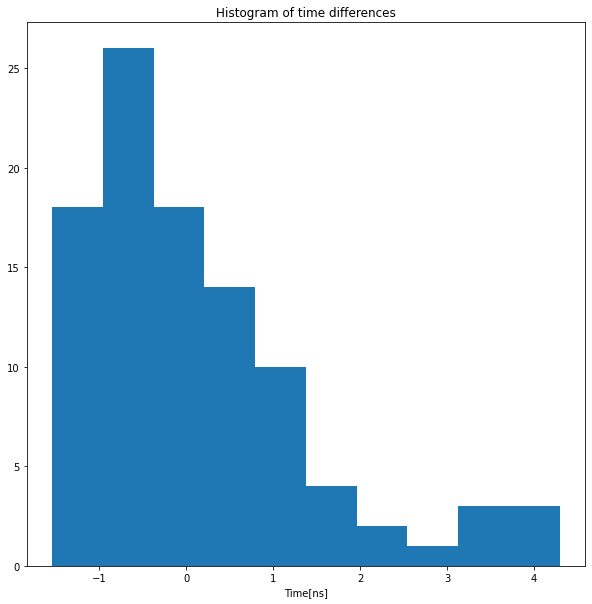

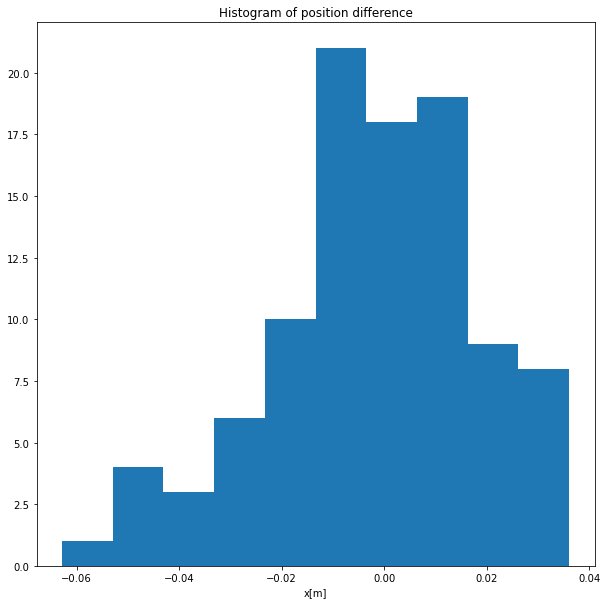

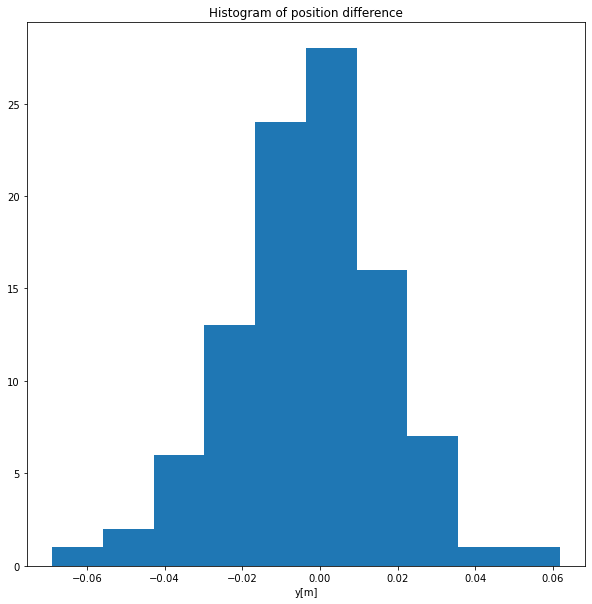

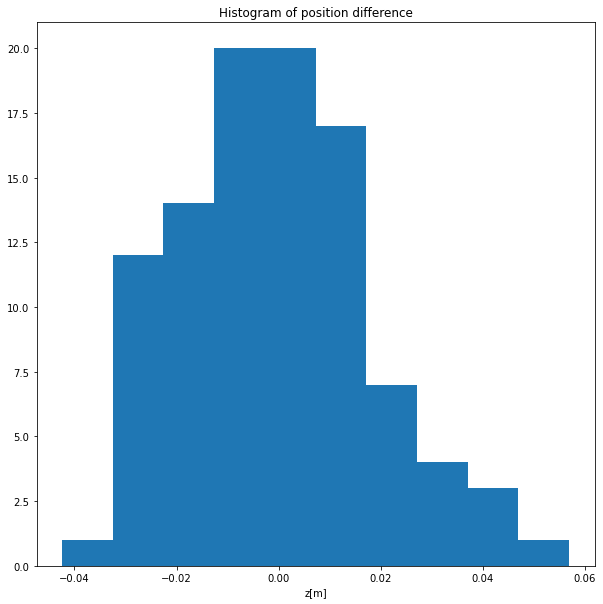

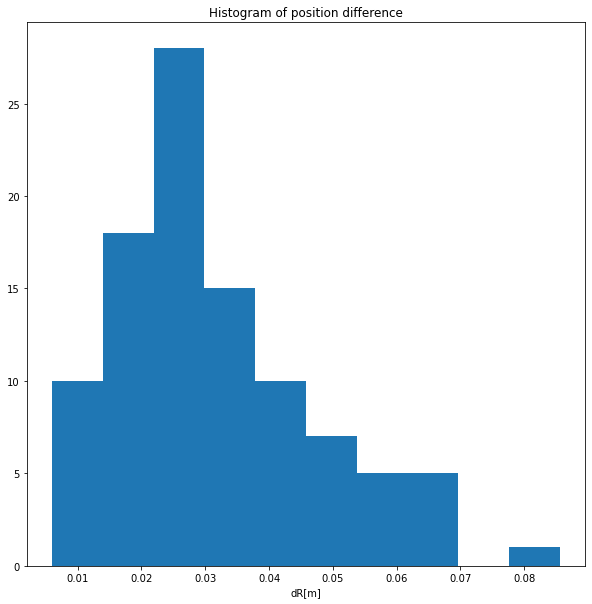

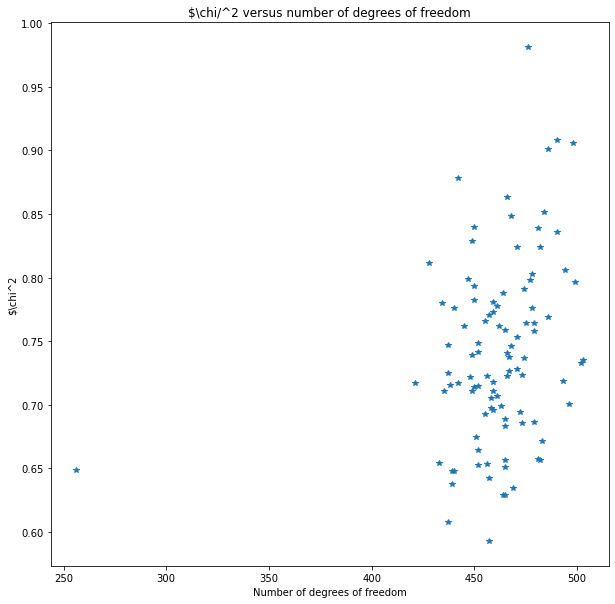

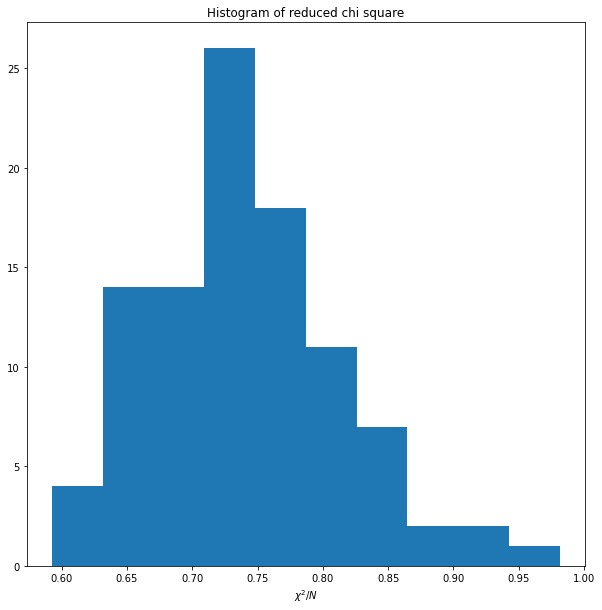

In [438]:
delt=[t0-sol[0] for pL,t0,v,sol,ch2,n in events]
plt.hist(delt)
plt.title("Histogram of time differences")
plt.xlabel("Time[ns]")
plt.show()

delx=[v[0]-sol[1] for pL,t0,v,sol,ch2,n in events]
plt.hist(delx)
plt.title("Histogram of position difference")
plt.xlabel("x[m]")
plt.show()

dely=[v[1]-sol[2] for pL,t0,v,sol,ch2,n in events]
plt.hist(dely)
plt.title("Histogram of position difference")
plt.xlabel("y[m]")
plt.show()

delz=[v[2]-sol[3] for pL,t0,v,sol,ch2,n in events]
plt.hist(delz)
plt.title("Histogram of position difference")
plt.xlabel("z[m]")
plt.show()

delr=[np.linalg.norm(v-sol[1:]) for pL,t0,v,sol,ch2,n in events]
plt.hist(delr)
plt.title("Histogram of position difference")
plt.xlabel("dR[m]")
plt.show()


chlist=[ch2/(n-4) for pL,t0,v,sol,ch2,n in events]
nlist=[n-4 for pL,t0,v,sol,ch2,n in events] #4 fit parameters

plt.plot(nlist,chlist,'*')
plt.title("$\chi/^2 versus number of degrees of freedom")
plt.xlabel("Number of degrees of freedom")
plt.ylabel("$\chi^2")
plt.show()

plt.hist(chlist)
plt.title("Histogram of reduced chi square")
plt.xlabel("$\chi^2/N$")
plt.show()

In [439]:
events[0][0].shape[0]

485

We go back and change the time distribution to a real gaussian instead of a double exponential.

In [440]:
sigmat=1.0
def event(N):
    #generate N photons
    rng=np.random.default_rng()
    z=(rng.random()-0.5)*6  #from -3 to 3
    rho=3*np.sqrt(rng.random())
    phi=2*rng.random()*np.pi
    v=np.array([rho*np.cos(phi),rho*np.sin(phi), z])
    t0=rng.random()*100  #generate a start time from 0-100 ns
    print('t0,v=',t0,v)
    
    #time generation
#    trise=rng.exponential(0.8,N)
#    tfast=rng.exponential(1,N)
#    tdecay=t0+trise+tfast
    tdecay=t0+rng.normal(0,sigmat,N)

    #generate directions
    costheta=rng.random(N)*2-1
    phi=rng.random(N)*np.pi*2
    sintheta=np.sqrt(1.0-costheta**2)
    directions=np.vstack([sintheta*np.cos(phi),sintheta*np.sin(phi),costheta])
    
    #calculate distances=time*speed of light to top, bottom, and barrel for each pmt
    dtop=(3-v[2])/directions[2]
    dbottom=(-3-v[2])/directions[2]
    radius=3
    dbarrel=[np.polynomial.Polynomial([np.dot(v[:2],v[:2])-RDisk**2,2*np.dot(dir[:2],v[:2]),np.dot(dir[:2],dir[:2])]).roots()
         [1] for dir in directions.transpose()]
    dtop[np.asarray(dtop<0).nonzero()]=np.infty
    dbottom[np.asarray(dbottom<0).nonzero()]=np.infty
    dlist=np.array([dtop,dbottom,dbarrel])
    d=np.min(dlist,axis=0)
    positions=(d*directions).transpose()+v
    
    pmtList=[]
    rand3=rng.random(N)
    for ev in zip(positions,tdecay,rand3):
        r,t0,r3=ev
        pmtN=pmtNumber(r)
        if np.linalg.norm(r-pmtCenter(pmtN))<Rpmt and r3<0.3:  #PMT border and efficiency tested
            time=t0+np.linalg.norm(r-v)/cn
            pmtList.append((pmtN,time))
    pmtList=np.array(pmtList)
    return(pmtList,t0,v)

events=[]
for i in range(1,100):
    pL,t0,v=event(2000)
    sol=minimize(chisquare,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
    events.append((pL,t0,v,sol.x,sol.fun,pL.shape[0]))


t0,v= 62.66252861407702 [-2.24838577  0.61898505 -2.19490216]
t0,v= 96.06281655436898 [-1.53332233  0.16493585  0.95747873]
t0,v= 13.978222802546192 [-0.62575457 -1.9370356   2.71926197]
t0,v= 17.80380322320737 [-0.32527624  1.86607093 -0.54306041]
t0,v= 89.25382352643189 [1.02543795 1.616937   2.98233591]
t0,v= 44.03346971916765 [-0.9767854  -0.61488317  0.41841815]
t0,v= 6.528839484373661 [ 0.21242915 -0.56735737 -0.16660506]
t0,v= 44.510818505824425 [-1.0259702   1.78231624 -0.48595902]
t0,v= 0.17774084895584297 [-2.90010767  0.43519968  1.40626207]
t0,v= 0.6763437208224254 [ 2.69236051  0.38014437 -0.81345312]
t0,v= 54.86378365102874 [-1.33799068  0.82103815 -2.72726798]
t0,v= 45.06122406459777 [ 1.68640388  0.22427497 -1.51118729]
t0,v= 32.411769214181305 [ 0.07090953  0.4597132  -1.08599834]
t0,v= 39.26753429285682 [-2.61170607  1.2453276   0.43546325]
t0,v= 48.82829774652302 [ 1.67842588 -1.1847824   0.00621252]
t0,v= 88.66058191522936 [ 0.62076604  2.45172612 -0.13012971]
t0,v=

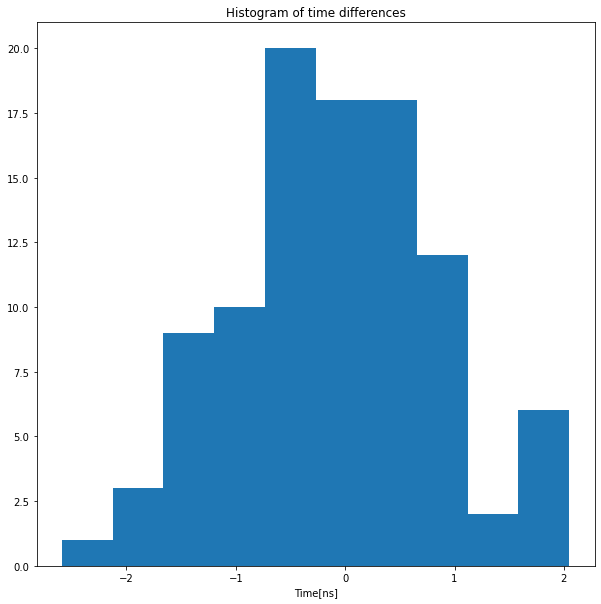

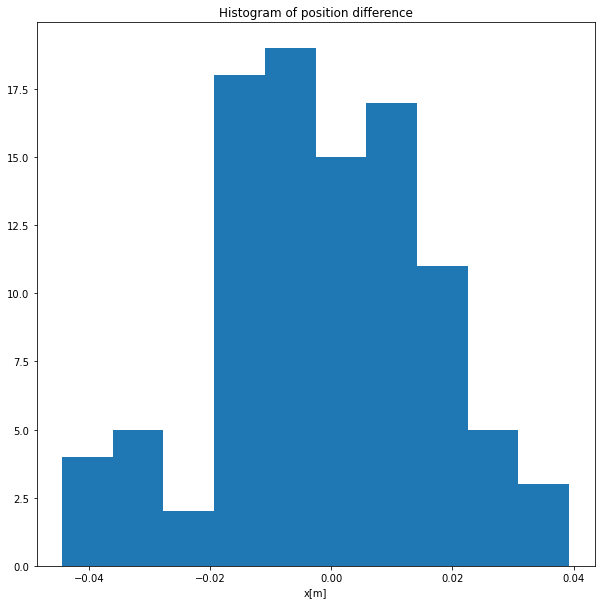

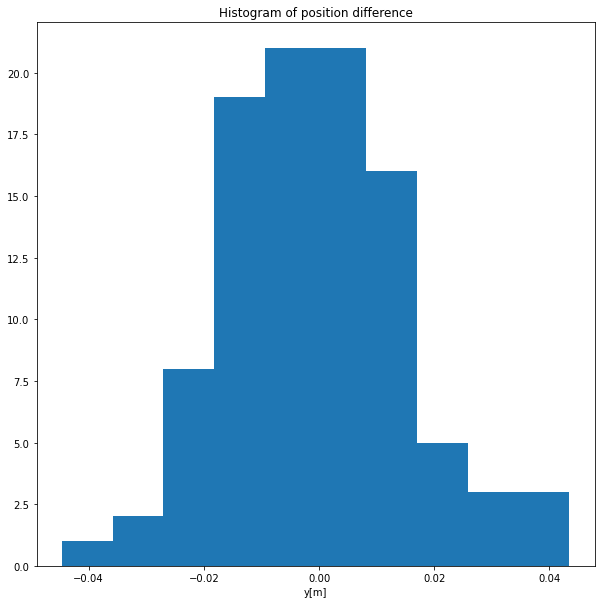

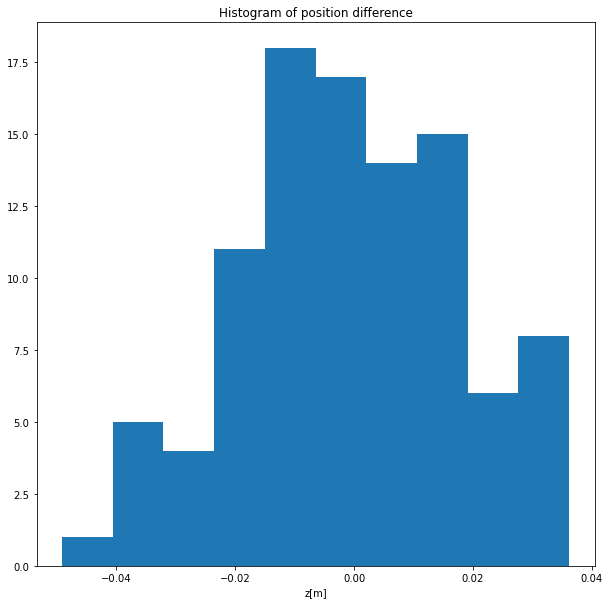

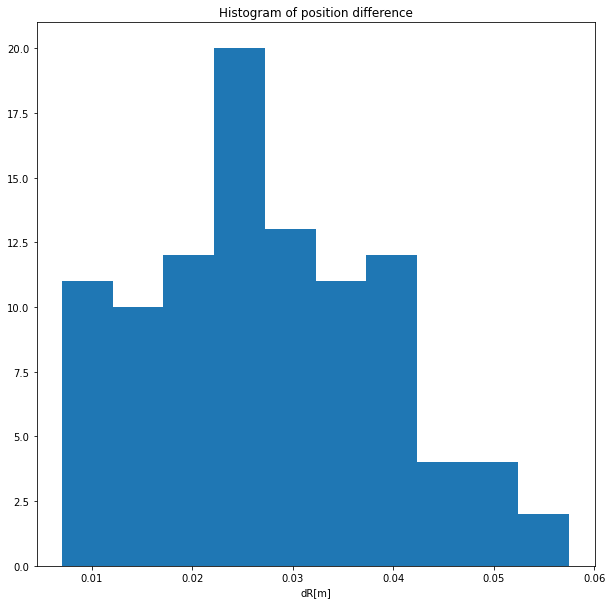

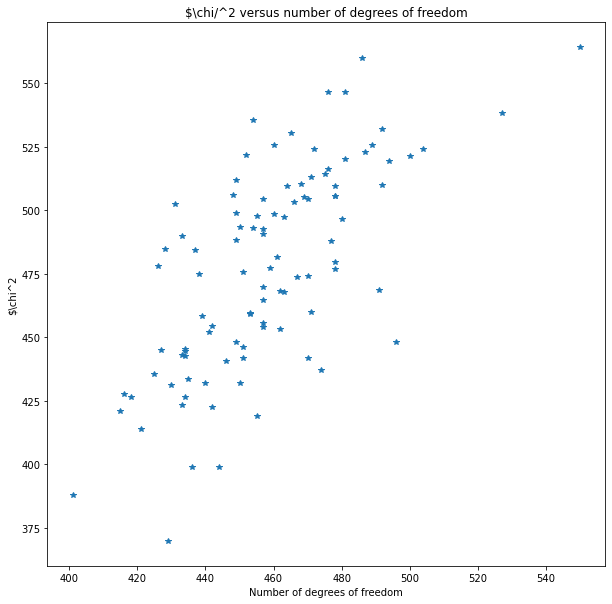

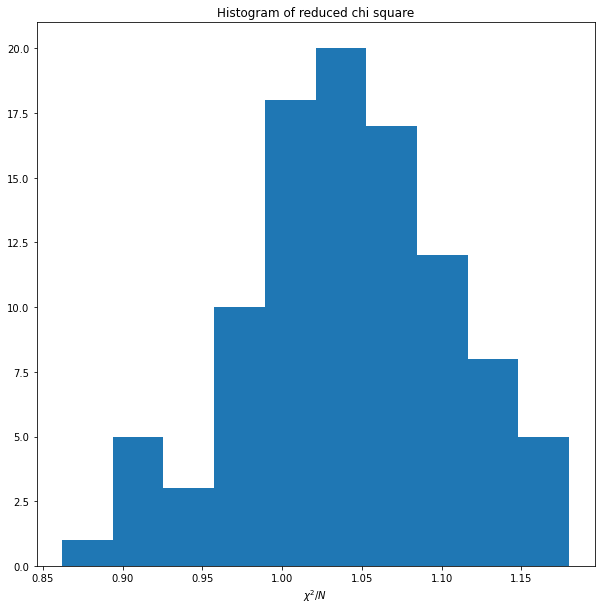

In [441]:
delt=[t0-sol[0] for pL,t0,v,sol,ch2,n in events]
plt.hist(delt)
plt.title("Histogram of time differences")
plt.xlabel("Time[ns]")
plt.show()

delx=[v[0]-sol[1] for pL,t0,v,sol,ch2,n in events]
plt.hist(delx)
plt.title("Histogram of position difference")
plt.xlabel("x[m]")
plt.show()

dely=[v[1]-sol[2] for pL,t0,v,sol,ch2,n in events]
plt.hist(dely)
plt.title("Histogram of position difference")
plt.xlabel("y[m]")
plt.show()

delz=[v[2]-sol[3] for pL,t0,v,sol,ch2,n in events]
plt.hist(delz)
plt.title("Histogram of position difference")
plt.xlabel("z[m]")
plt.show()

delr=[np.linalg.norm(v-sol[1:]) for pL,t0,v,sol,ch2,n in events]
plt.hist(delr)
plt.title("Histogram of position difference")
plt.xlabel("dR[m]")
plt.show()


chlist=np.array([ch2 for pL,t0,v,sol,ch2,n in events])
nlist=np.array([n-4 for pL,t0,v,sol,ch2,n in events]) #4 fit parameters

plt.plot(nlist,chlist,'*')
plt.title("$\chi/^2 versus number of degrees of freedom")
plt.xlabel("Number of degrees of freedom")
plt.ylabel("$\chi^2")
plt.show()

plt.hist(chlist/nlist)
plt.title("Histogram of reduced chi square")
plt.xlabel("$\chi^2/N$")
plt.show()

4.7627805092949185 [ 0.71457745 -2.07596143  2.80506624]


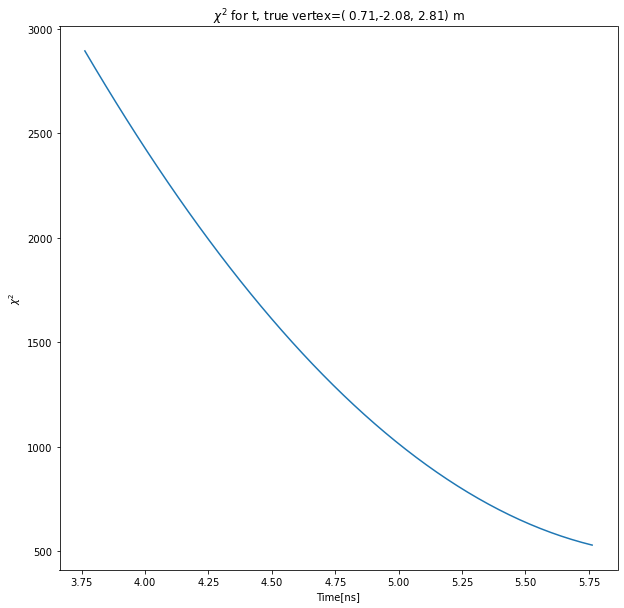

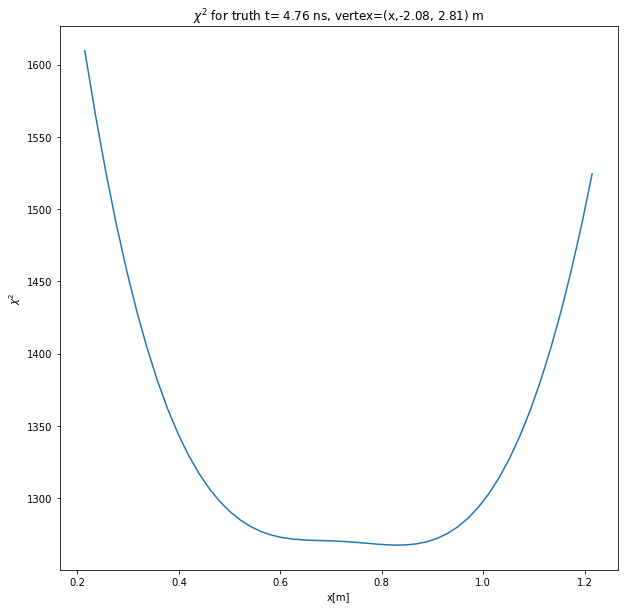

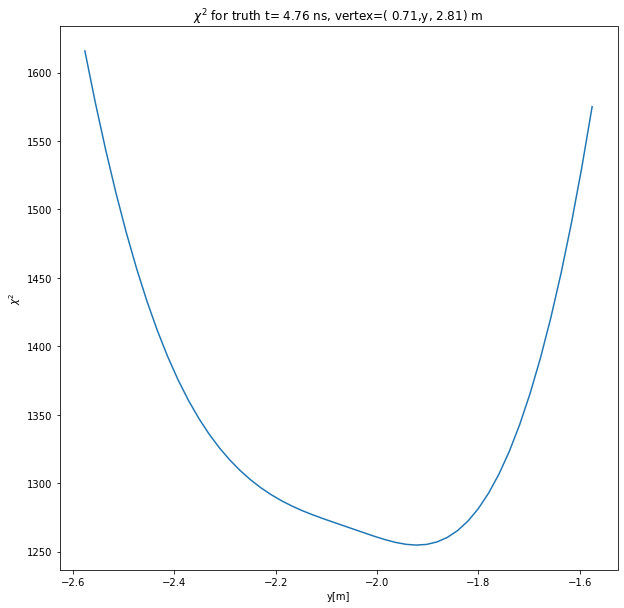

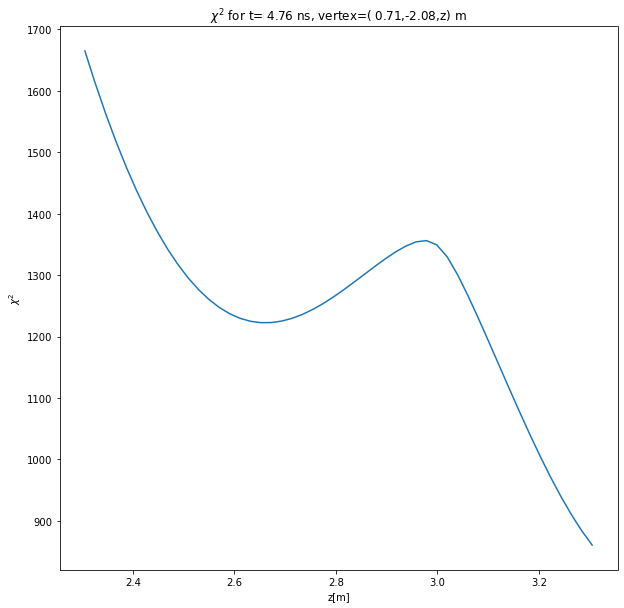

Minimum chisquare is 8.6e+02 for442 degrees of freedom.


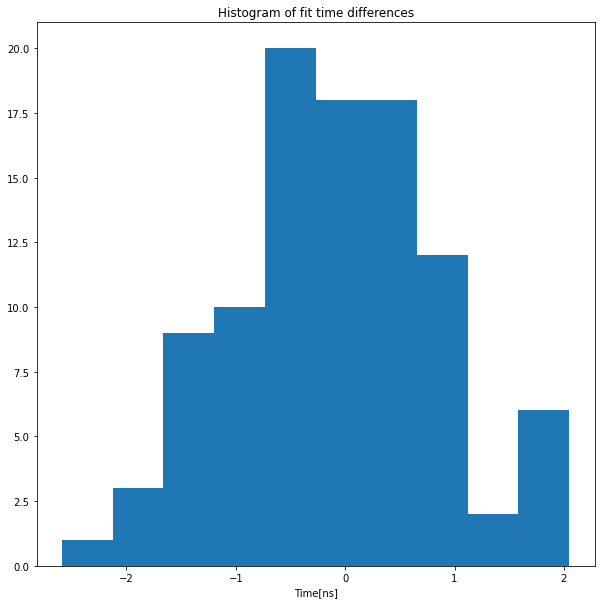

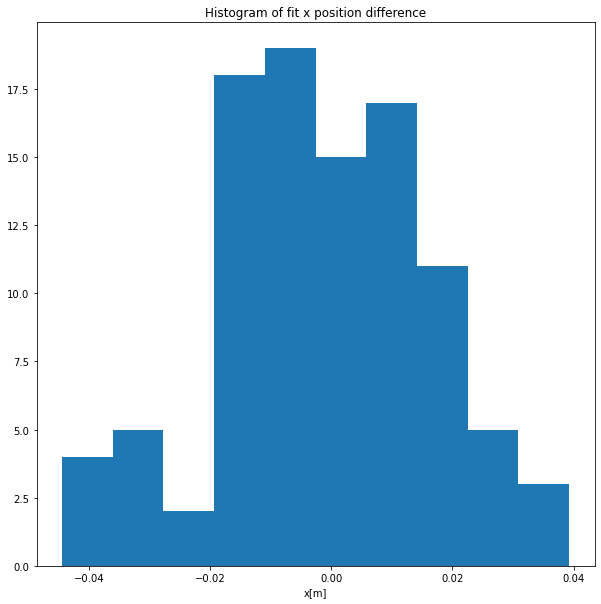

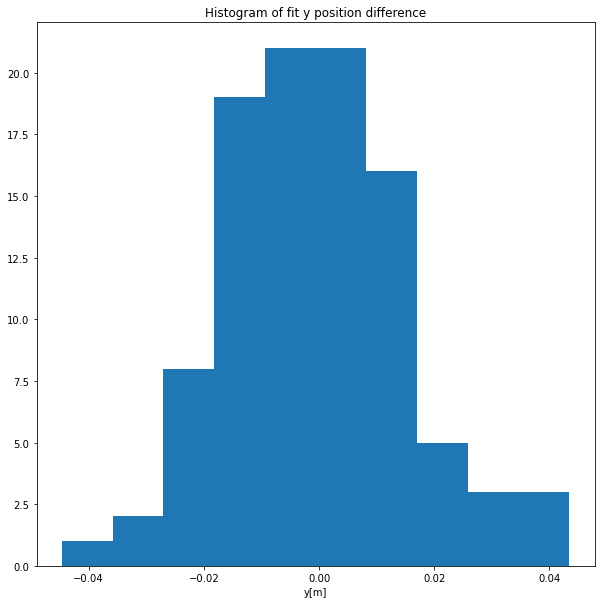

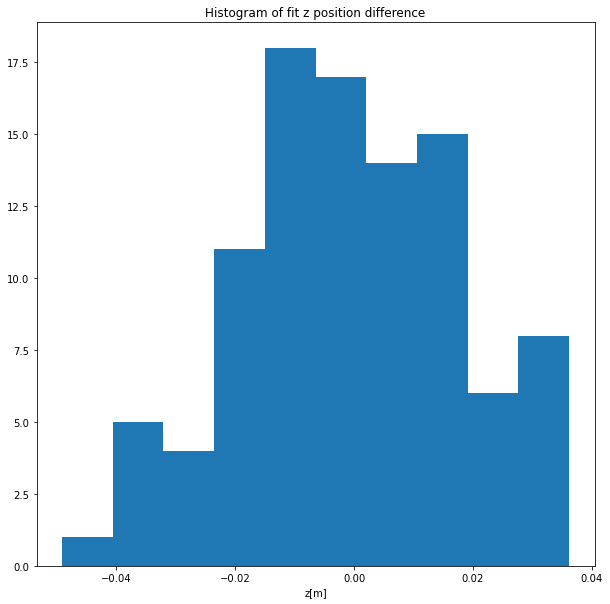

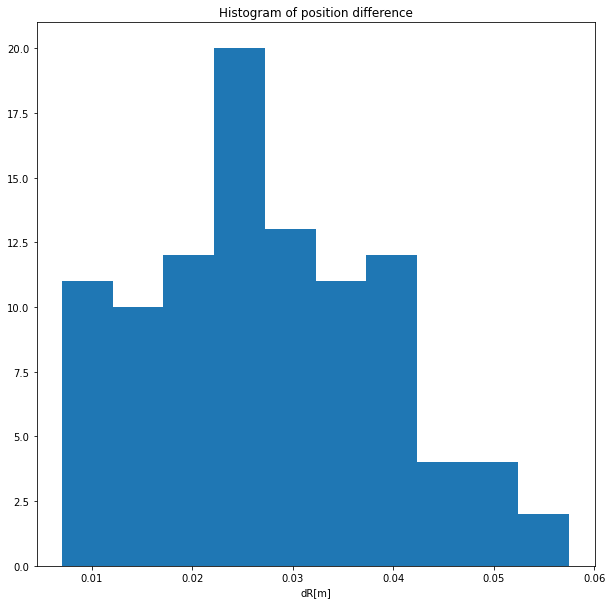

In [442]:
#plats around truth t0,vertex
pL,t0,v,sol,ch2,n=events[20]
print(t0,v)
tlist=np.linspace(t0-1,t0+1)
chilist=[chisquare(np.array([t,v[0],v[1],v[2]]),pL) for t in tlist]
plt.plot(tlist,chilist)
plt.title(f'$\chi^2$ for t, true vertex=({v[0]:5.2f},{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[0]-.5,v[0]+0.5)
chilist=[chisquare(np.array([t0,x,v[1],v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for truth t={t0:5.2f} ns, vertex=(x,{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("x[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[1]-.5,v[1]+0.5)
chilist=[chisquare(np.array([t0,v[0],x,v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for truth t={t0:5.2f} ns, vertex=({v[0]:5.2f},y,{v[2]:5.2f}) m')
plt.xlabel("y[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[2]-.5,v[2]+0.5)
chilist=[chisquare(np.array([t0,v[0],v[1],x]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},{v[1]:5.2f},z) m')
plt.xlabel("z[m]")
plt.ylabel("$\chi^2$")
plt.show()

print(f'Minimum chisquare is {np.min(chilist):5.2} for{len(pL)} degrees of freedom.')

delt=[t0-sol[0] for pL,t0,v,sol,ch2,n in events]
plt.hist(delt)
plt.title("Histogram of fit time differences")
plt.xlabel("Time[ns]")
plt.show()

delx=[v[0]-sol[1] for pL,t0,v,sol,ch2,n in events]
plt.hist(delx)
plt.title("Histogram of fit x position difference")
plt.xlabel("x[m]")
plt.show()

dely=[v[1]-sol[2] for pL,t0,v,sol,ch2,n in events]
plt.hist(dely)
plt.title("Histogram of fit y position difference")
plt.xlabel("y[m]")
plt.show()

delz=[v[2]-sol[3] for pL,t0,v,sol,ch2,n in events]
plt.hist(delz)
plt.title("Histogram of fit z position difference")
plt.xlabel("z[m]")
plt.show()

delr=[np.linalg.norm(v-sol[1:]) for pL,t0,v,sol,ch2,n in events]
plt.hist(delr)
plt.title("Histogram of position difference")
plt.xlabel("dR[m]")
plt.show()

# Uncertainties on fit

For a chisquare fit, with normal uncertainties, we can find the "single parameter errors" by taking the square root of the inverse hessian elements.  If we allow several parameters to vary at once, it gets more complicated- see for instance Hughes and Hase or NR.  

In [443]:
pL,t0,v=event(2000)
sol=minimize(chisquare,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
print('sol.x=',sol.x)
print(sol)

t0,v= 99.91876876489974 [-0.1598305  -1.19179412  2.60404601]
sol.x= [99.82426666 -0.16460648 -1.16401602  2.61298835]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 489.7497058395436
        x: [ 9.982e+01 -1.646e-01 -1.164e+00  2.613e+00]
      nit: 14
      jac: [ 5.116e-05 -2.274e-05  0.000e+00  2.842e-05]
     nfev: 80
     njev: 16
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


In [444]:
C=sol.hess_inv.todense()
print(C)
print(f'''t={sol.x[0]:5.2f}\u00B1{np.sqrt(C[0,0]):5.2f}ns, x,y,z=({sol.x[1]:5.2f}\u00B1{np.sqrt(C[1,1]):5.2f},
     {sol.x[2]:5.2f}\u00B1{np.sqrt(C[2,2]):5.2f},{sol.x[3]:5.2f}\u00B1{np.sqrt(C[3,3]):5.2f}) m''')

[[ 0.06470969 -0.09365117 -0.12033565  0.03839624]
 [-0.09365117  0.15569025  0.19179571 -0.06210739]
 [-0.12033565  0.19179571  0.2399982  -0.07727108]
 [ 0.03839624 -0.06210739 -0.07727108  0.02508308]]
t=99.82± 0.25ns, x,y,z=(-0.16± 0.39,
     -1.16± 0.49, 2.61± 0.16) m


$\pm$

In [445]:
print(f'The chi2 probability of {sol.fun:6.2f} for {pL.shape[0]} dof is {chi2.cdf(sol.fun,pL.shape[0])}.')

The chi2 probability of 489.75 for 435 dof is 0.9645370630718435.


## Likelihood Fit

The physics doesn't always allow us to change things to make them into nice Gaussian distributions that can be done with $\chi^2$ fitting.  However, we can do a likelihood fit-- this basically asks us to define the probability of getting the data, given some set of parameters.  Thus, for our original time distribution, we had the assumption that the scintillator generates 80% of its photons with a 5 ns decay time, and 20% with a 100 ns decay time. We will also impose a 0.8 ns rise time; we can do this by assuming that there is a state with a 0.8ns decay time that generates the photons.  All these times are "livetimes"-- ie. 1/e times rather than half lives.

We define the likelihood of our measured times:
$$\mathscr{L}(t_0,\vec{v})=\prod_{i=0}^N P(t_i)$$
where $P(t_i)$ is the probability that PMT $i$ measures a photon from an event that occured at time $t_0$ at time $t_i.$  We can evaluate the probability:
$$ P(t_i;t_0)=\lambda \int_{t_0}^{t_i-t_f}dt' e^{-\lambda(t'-t_0)} \left(0.16 e^{-\frac{t_i-t_f-t'}{5}}+0.002 e^{-\frac{t_i-t_f-t'}{100}}\right) $$

with the time of flight between vertex $\vec{v}$ and pmt position $\vec{p}_i$ is $t_f=\frac{|\vec{p}_i-\vec{v}|}{v_g}.$  The group velocity of light in scintillator is $v_g.$  The 0.16 normalizes the first exponential to 0.80 and the 0.002 normalizes the second to 0.20.

We can do the integral numerically.  It is straightforward to "start the clock" at time $t0$ and to ignore the time of flight, for now.  

Note that a chisquared fit is just a likelihood fit where the probability distribution is a gaussian.

(0.9969948092862656, 8.35569814272513e-09)

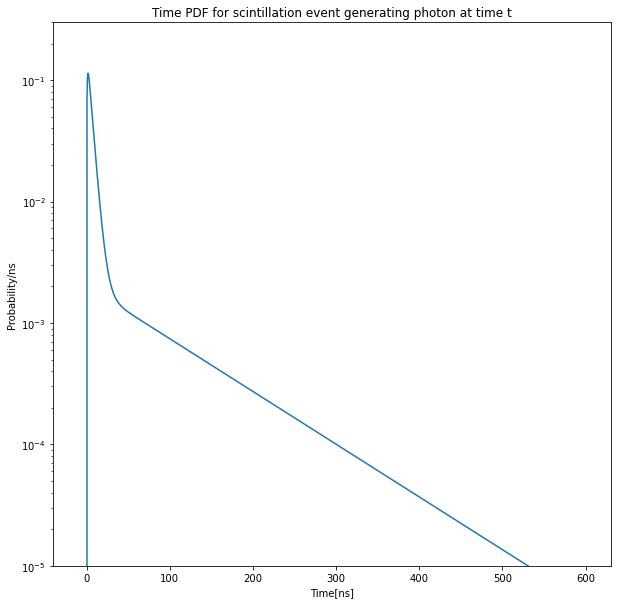

In [500]:
l=1.0/0.8
def func(t,t2):
    if t>0:
        return l*np.exp(-l*t)*(0.16*np.exp(-(t2-t)/5)+0.002*np.exp(-(t2-t)/100))
    else:
        return 0
from scipy.integrate import quad
t2list=np.linspace(-10,600,1221)
ilist=np.array([quad(func,0,t2,args=(t2,))[0] for t2 in t2list])
plt.plot(t2list,ilist)
plt.ylim(1e-5,0.3)
plt.yscale('log')
plt.title("Time PDF for scintillation event generating photon at time t")
plt.xlabel("Time[ns]")
plt.ylabel("Probability/ns")

from scipy.interpolate import CubicSpline
pdfa=CubicSpline(t2list,ilist)

quad(pdfa,0.,600)


This is nice. But we want to "tweak" it a bit- so that we don't have a discontinuous derivative at 0.  We do this by convolving a response function-- that is the probability that a pmt will measure a time tm if hit by a photon at time t.  

Convolution is
$$P(t_m)=\int_{-\infty}^{\infty} P(t)P_m(t;t_m)dt $$
where $t_m$ is the measured time, $t$ is the time the photon struck the pmt, and $P_m$ is the "response function"- which gives the probability that we measure $t_m$ when the actual time is $t$.

For a gaussian response $$P_m(t;t_m)=\frac{1}{\sqrt{2\pi}\sigma} e^\frac{(t_m-t)^2}{2\sigma^2}.$$ It may seem counterintuitive that we can have $t_m\lt t$, but we typically calibrate the time offsets so the most likely measured time is the same as the hit time.  
 
We actually don't need to normalize the PDF's, because we end up maximizing and the actual value of the PDF in a likelihood fit is typically quite complex.  So we simplify $$P_m(t;t_m)= e^\frac{(t_m-t)^2}{2\sigma^2}.$$

There are easy ways to convolve with fourier transforms-- a convolution in the time domain is the same as a multiplication of fourier transforms in frequency space.  scipy.signal.convolve allows us to do a convolution of two arrays, and picks whether a time domain integration is more or less efficient than the fourier transform multiplication.

In [447]:
np.exp(-50)

1.9287498479639178e-22

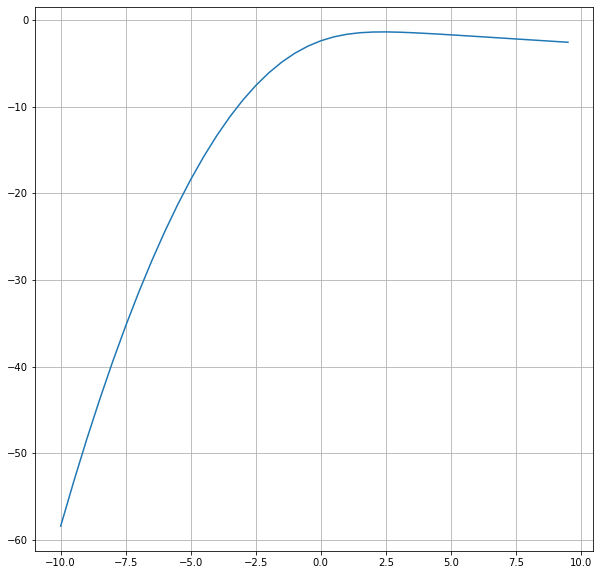

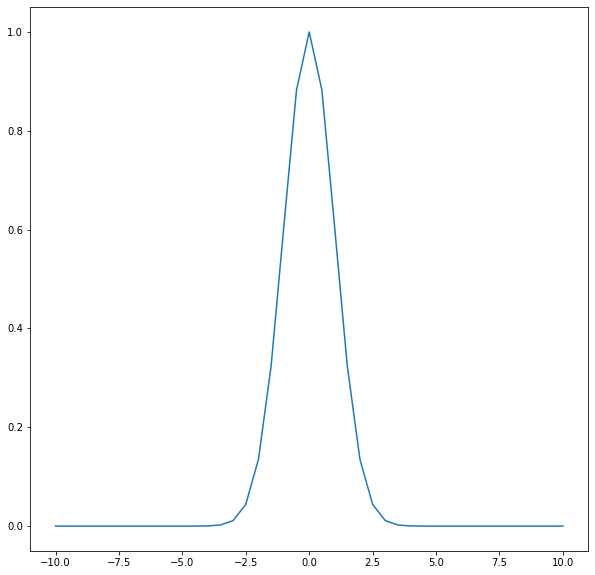

In [523]:
def pdfm(t,tm,sig):  # we want this to be a function of t because we integrate over t, and this is the function we will integrate with quad
    return pdfa(t)*np.exp(-(tm-t)**2/2/sig**2)

s=1

pdfml=np.array([quad(pdfm,tm-10*s,tm+10*s,args=(tm,s))[0] for tm in t2list]) #integrating over 10 sigma is fine- since e(-50)=2e-22

pdf=CubicSpline(t2list[11:],np.log(pdfml[11:])) #interpolate in log
plt.plot(t2list[:40],pdf(t2list[:40]))
#plt.yscale('log')
#plt.ylim(1e-5,0.3)
plt.grid()
plt.show()


from scipy.signal import convolve
tt=np.linspace(-10,10,41)
def g(t,s):
    return np.exp(-t**2/2/s**2)
plt.plot(tt,g(tt,1))


In [524]:
pdf(-30)

array(-488.05862856)

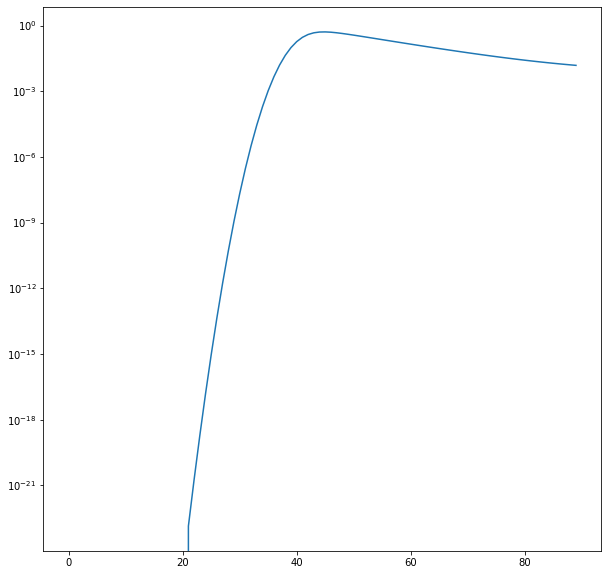

In [402]:
cc=convolve(ilist,g(tt,1))
plt.plot(cc[:90])
plt.yscale('log')

We will simply use our integration to determine log(pdfm).

In [525]:
# make event have the time structure we originally put forward
def event(N):
    #generate N photons
    rng=np.random.default_rng()
    z=(rng.random()-0.5)*6  #from -3 to 3
    rho=3*np.sqrt(rng.random())
    phi=2*rng.random()*np.pi
    v=np.array([rho*np.cos(phi),rho*np.sin(phi), z])
    t0=rng.random()*100  #generate a start time from 0-100 ns
    print('t0,v=',t0,v)
    
    #time generation
    trise=rng.exponential(0.8,N)
    tfast=rng.exponential(5,N)
    tslow=rng.exponential(100,N)
    select=rng.random(N)
    tdecay=t0+trise+np.where(select<0.8,tfast,tslow)

    #generate directions
    costheta=rng.random(N)*2-1
    phi=rng.random(N)*np.pi*2
    sintheta=np.sqrt(1.0-costheta**2)
    directions=np.vstack([sintheta*np.cos(phi),sintheta*np.sin(phi),costheta])
    
    #calculate distances=time*speed of light to top, bottom, and barrel for each pmt
    dtop=(3-v[2])/directions[2]
    dbottom=(-3-v[2])/directions[2]
    radius=3
    dbarrel=[np.polynomial.Polynomial([np.dot(v[:2],v[:2])-RDisk**2,2*np.dot(dir[:2],v[:2]),np.dot(dir[:2],dir[:2])]).roots()
         [1] for dir in directions.transpose()]
    dtop[np.asarray(dtop<0).nonzero()]=np.infty
    dbottom[np.asarray(dbottom<0).nonzero()]=np.infty
    dlist=np.array([dtop,dbottom,dbarrel])
    d=np.min(dlist,axis=0)
    positions=(d*directions).transpose()+v
    
    pmtList=[]
    rand3=rng.random(N)
    for ev in zip(positions,tdecay,rand3):
        r,tt,r3=ev
        pmtN=pmtNumber(r)
        if np.linalg.norm(r-pmtCenter(pmtN))<Rpmt and r3<0.3:  #PMT border and efficiency tested
            time=tt+np.linalg.norm(r-v)/cn
            pmtList.append((pmtN,time))
    pmtList=np.array(pmtList)
    return(pmtList,t0,v)

def NLLikelihood(xarg,pmtList):
    'Negative log likelihood'
    t=xarg[0]
    x=xarg[1:4]
    p2=np.array([pmtCenter(int(i)) for i in pmtList[:,0]])
    tof=np.linalg.norm(p2-x,axis=1)/cn
    times=pmtList[:,1]-t-tof
#    ll=np.zeros_like(times)
#    ll[np.asarray(times<0).nonzero()]=0.001
#    ll[np.asarray(times>600).nonzero()]=1e-5
#    good=np.asarray((0<times) & (times<600)).nonzero()
    ll=pdf(times)
#    print(t,x,-np.sum(ll),'ll=',ll[:20])
#    ll[np.asarray(np.abs(ll)<1e-5).nonzero()]=1e-5
#    print(ll)
#    bad=np.asarray(ll<0).nonzero()
#    if len(bad[0])>0:
#        print('bad',bad,ll[bad],times[bad])
#    ll=np.log(ll)
#print('log',ll)
#    ll[np.assarray((0<times)&(times<500),pdf(times),1e-5)  # necessary because tiny probabilities get huge weight!
    return -np.sum(ll)

pL,t0,v=event(2000)
sol=minimize(NLLikelihood,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
print('sol.x=',sol.x)
print(sol)
print(t0,v)

t0,v= 49.44951906797589 [ 0.12526859  2.30329588 -2.66546106]
sol.x= [49.71530833  0.09718696  2.23889172 -2.67753717]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 1125.6216545884754
        x: [ 4.972e+01  9.719e-02  2.239e+00 -2.678e+00]
      nit: 25
      jac: [-1.137e-04 -1.364e-04  9.095e-05  2.274e-05]
     nfev: 210
     njev: 42
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
49.44951906797589 [ 0.12526859  2.30329588 -2.66546106]


In [526]:
help(minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
    Minimization of scalar function of one or more variables.
    
    Parameters
    ----------
    fun : callable
        The objective function to be minimized.
    
            ``fun(x, *args) -> float``
    
        where ``x`` is a 1-D array with shape (n,) and ``args``
        is a tuple of the fixed parameters needed to completely
        specify the function.
    x0 : ndarray, shape (n,)
        Initial guess. Array of real elements of size (n,),
        where ``n`` is the number of independent variables.
    args : tuple, optional
        Extra arguments passed to the objective function and its
        derivatives (`fun`, `jac` and `hess` functions).
    method : str or callable, optional
        Type of solver.  Should be one of
    
            - 'Nelder-Mead' :ref:`(see he

In [546]:
def NLLikelihood(xarg,pmtList):
    'Negative log likelihood'
    t=xarg[0]
    x=xarg[1:4]
    p2=np.array([pmtCenter(int(i)) for i in pmtList[:,0]])
    tof=np.linalg.norm(p2-x,axis=1)/cn
    times=pmtList[:,1]-t-tof
    ll=pdf(times)
#    print(t,x,-np.sum(ll),'ll=',ll[:5],times[:5],tof[:5])
    return -np.sum(ll)

def jacNLL(xarg,pmtList):
    t=xarg[0]
    x=xarg[1:4]
    p2=np.array([pmtCenter(int(i)) for i in pmtList[:,0]])
    tof=np.linalg.norm(p2-x,axis=1)/cn
#    print('tof',tof[:10])
    times=pmtList[:,1]-t-tof
#    print('times',times[:10],pdf(times[:10]))
    l0=(-np.sum(pdf(times-0.1))+np.sum(pdf(times+0.1)))/0.2
    dx=np.array([0.001,0,0])
    dy=np.array([0,0.001,0])
    dz=np.array([0.0,0,0.001])
    l1=(-np.sum(pdf( pmtList[:,1]- t- np.linalg.norm(p2-x-dx,axis=1)/cn ))+np.sum(pdf(pmtList[:,1]-t-np.linalg.norm(p2-x+dx,axis=1)/cn)))/0.002
#    print(p2[:10],(p2-x-dx)[:10],np.linalg.norm(p2-x-dx,axis=1)[:10])
    l2=(-np.sum(pdf(pmtList[:,1]-t-np.linalg.norm(p2-x-dy,axis=1)/cn))+np.sum(pdf(pmtList[:,1]-t-np.linalg.norm(p2-x+dy,axis=1)/cn)))/0.002
    l3=(-np.sum(pdf(pmtList[:,1]-t-np.linalg.norm(p2-x-dz,axis=1)/cn))+np.sum(pdf(pmtList[:,1]-t-np.linalg.norm(p2-x+dz,axis=1)/cn)))/0.002
    return np.array([l0,l1,l2,l3])

sol=minimize(NLLikelihood,[20,0,0,0],args=pL,jac=jacNLL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
print('sol.x=',sol.x)
print(sol)
print(t0,v)
#xarg=np.concatenate((np.array([t0]),v))
#NLLikelihood(xarg,pL)
#jacNLL(xarg,pL)
#    print(t,x,-np.sum(ll),'ll=',ll[:20])
#    return -np.sum(ll)

sol.x= [49.71433147  0.09716317  2.23887693 -2.6775729 ]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 1125.6216814670133
        x: [ 4.971e+01  9.716e-02  2.239e+00 -2.678e+00]
      nit: 29
      jac: [ 1.839e-04 -3.871e-04  2.164e-04 -2.824e-04]
     nfev: 60
     njev: 60
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
49.44951906797589 [ 0.12526859  2.30329588 -2.66546106]


In [543]:
cn

0.19986163866666667

49.44951906797589 [ 0.12526859  2.30329588 -2.66546106]


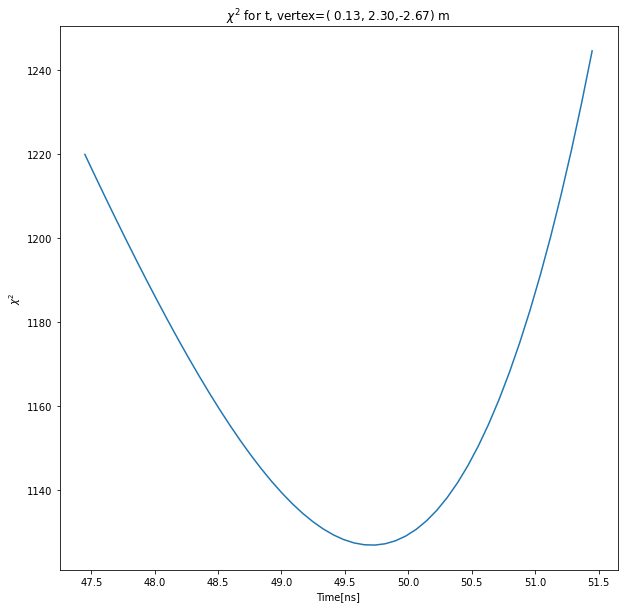

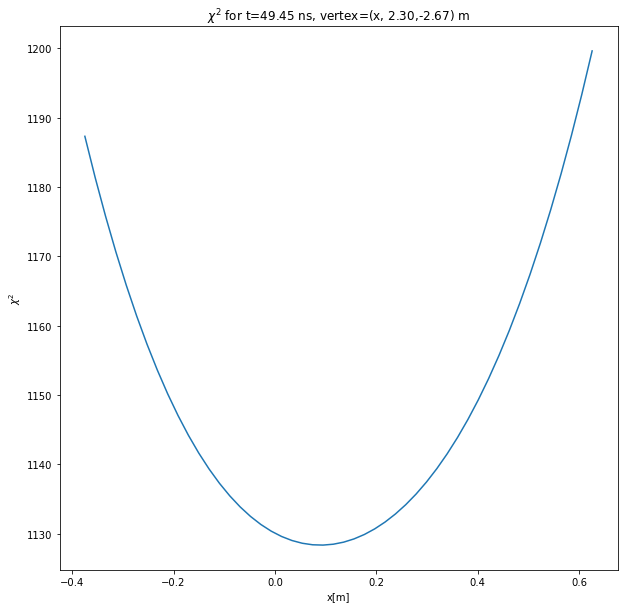

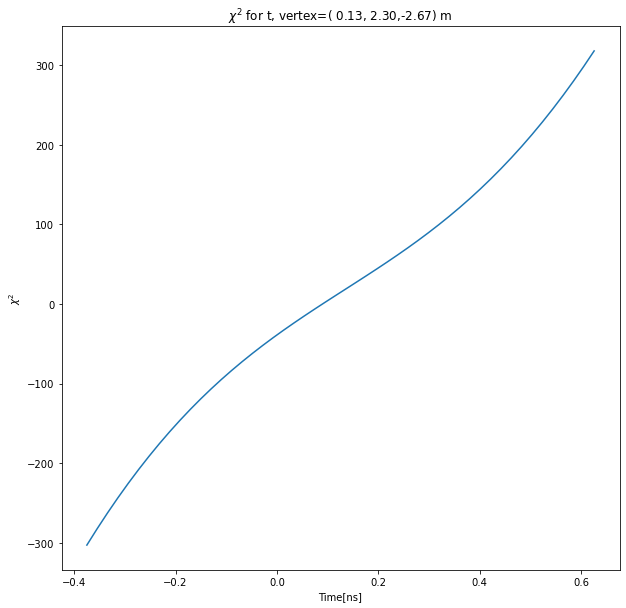

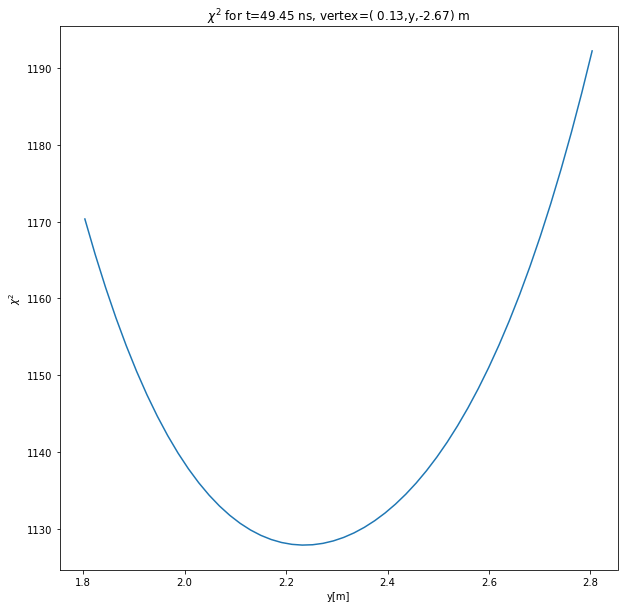

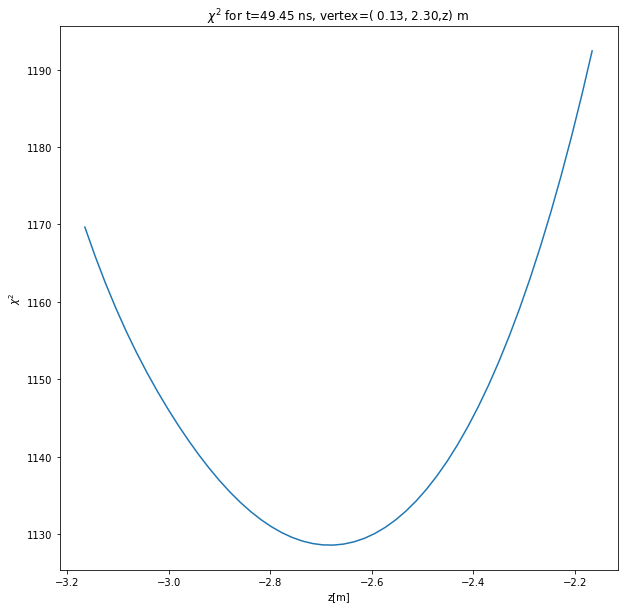

In [545]:
#t0=sol.x[0]
#v=sol.x[1:]
print(t0,v)

tlist=np.linspace(t0-2,t0+2)
chilist=[NLLikelihood(np.array([t,v[0],v[1],v[2]]),pL) for t in tlist]
plt.plot(tlist,chilist)
plt.title(f'$\chi^2$ for t, vertex=({v[0]:5.2f},{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[0]-.5,v[0]+0.5)
chilist=[NLLikelihood(np.array([t0,x,v[1],v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=(x,{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("x[m]")
plt.ylabel("$\chi^2$")
plt.show()
chilist=[jacNLL(np.array([t0,x,v[1],v[2]]),pL)[1] for x in xlist]
#chilist2=[jacNLL(np.array([t0,x,v[1],v[2]]),pL)[2] for x in xlist]

plt.plot(xlist,chilist)
#plt.plot(xlist,chilist2)
plt.title(f'$\chi^2$ for t, vertex=({v[0]:5.2f},{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[1]-.5,v[1]+0.5)
chilist=[NLLikelihood(np.array([t0,v[0],x,v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},y,{v[2]:5.2f}) m')
plt.xlabel("y[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[2]-.5,v[2]+0.5)
chilist=[NLLikelihood(np.array([t0,v[0],v[1],x]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},{v[1]:5.2f},z) m')
plt.xlabel("z[m]")
plt.ylabel("$\chi^2$")
plt.show()


In [482]:
p

array([[ 2.88000000e+00,  0.00000000e+00, -3.00000000e+00],
       [ 2.86989943e+00,  2.40992189e-01, -3.00000000e+00],
       [ 2.83966859e+00,  4.80293991e-01, -3.00000000e+00],
       [ 2.78951950e+00,  7.16226875e-01, -3.00000000e+00],
       [ 2.71980395e+00,  9.47135943e-01, -3.00000000e+00],
       [ 2.63101092e+00,  1.17140153e+00, -3.00000000e+00],
       [ 2.52376324e+00,  1.38745058e+00, -3.00000000e+00],
       [ 2.39881317e+00,  1.59376766e+00, -3.00000000e+00],
       [ 2.25703716e+00,  1.78890561e+00, -3.00000000e+00],
       [ 2.09942965e+00,  1.97149567e+00, -3.00000000e+00],
       [ 1.92709615e+00,  2.14025710e+00, -3.00000000e+00],
       [ 1.74124545e+00,  2.29400616e+00, -3.00000000e+00],
       [ 1.54318117e+00,  2.43166443e+00, -3.00000000e+00],
       [ 1.33429258e+00,  2.55226631e+00, -3.00000000e+00],
       [ 1.11604489e+00,  2.65496588e+00, -3.00000000e+00],
       [ 8.89968944e-01,  2.73904277e+00, -3.00000000e+00],
       [ 6.57650506e-01,  2.80390724e+00

In [547]:
def NLLikelihood(xarg,pmtList):
    'Negative log likelihood'
    t=xarg[0]
    x=xarg[1:4]
    p2=np.array([pmtCenter(int(i)) for i in pmtList[:,0]])
    tof=np.linalg.norm(p2-x,axis=1)/cn
    times=pmtList[:,1]-t-tof
    ll=pdf(times)
#    ll[np.asarray(np.abs(ll)<1e-5).nonzero()]=1e-5
#    print(ll)
#    bad=np.asarray(ll<0).nonzero()
#    if len(bad[0])>0:
#        print('bad',xarg,bad,ll[bad],times[bad])
#    ll=np.log(ll)
#    ll=np.zeros_like(times)
#    ll[np.asarray(times<1e-4).nonzero()]=pdf(1e-4)
#    ll[np.asarray(times>500).nonzero()]=pdf(500)
#    good=np.asarray((1e-4<=times) & (times<=500)).nonzero()
#    ll[good]=pdf(times[good])
#    ll=np.log(ll)
#    ll[np.assarray((0<times)&(times<500),pdf(times),1e-5)  # necessary because tiny probabilities get huge weight!
    return -np.sum(ll)

pL,t0,v=event(2000)
sol=minimize(NLLikelihood,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
print('sol.x=',sol.x)
print(sol)
NLLikelihood([83,2.25,.511,-1.33],pL)

t0,v= 79.87528508482457 [1.60387118 1.01040631 2.33241078]
sol.x= [80.12136564  1.6511356   1.03079377  2.34482326]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 1280.0515560323997
        x: [ 8.012e+01  1.651e+00  1.031e+00  2.345e+00]
      nit: 26
      jac: [-8.640e-04  1.273e-03  2.228e-03 -4.775e-04]
     nfev: 245
     njev: 49
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


23856.178046680187

79.87528508482457 [1.60387118 1.01040631 2.33241078]


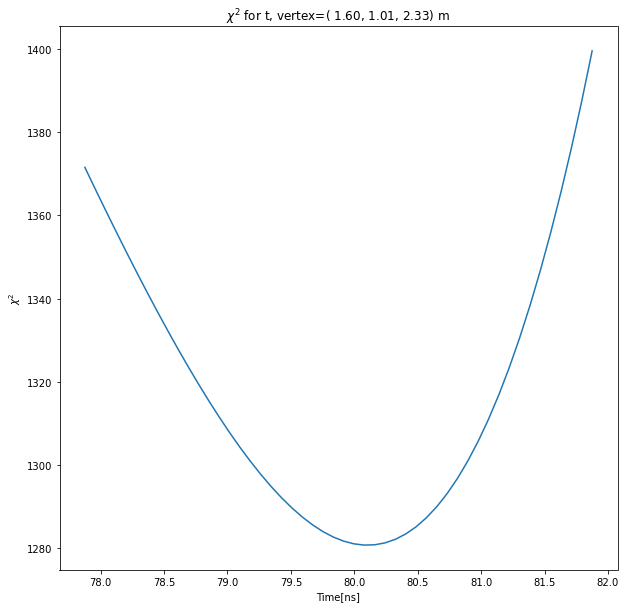

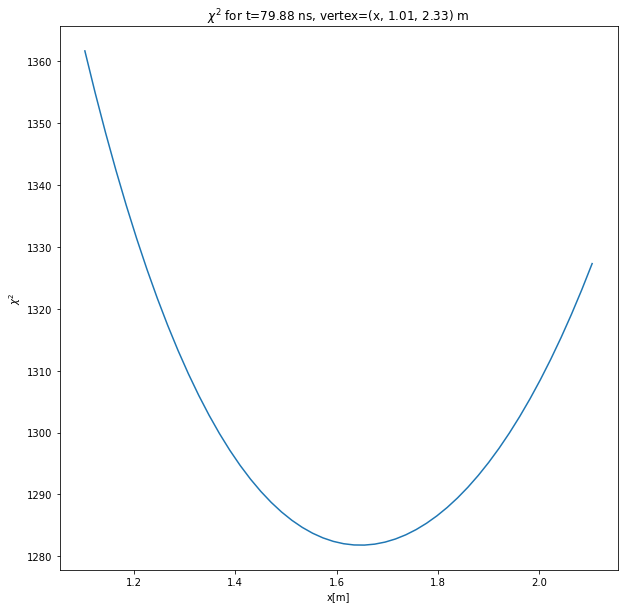

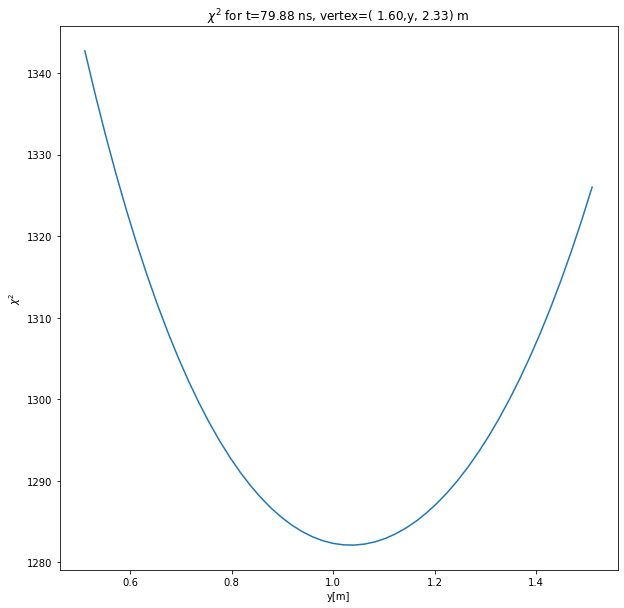

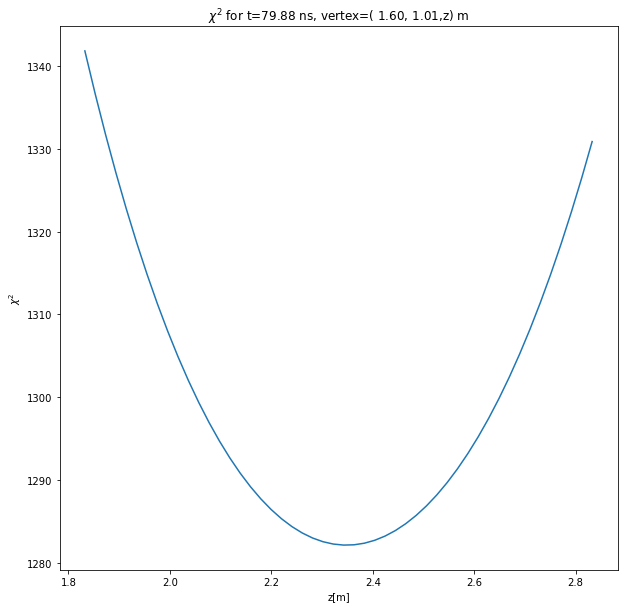

In [548]:
print(t0,v)
tlist=np.linspace(t0-2,t0+2)
chilist=[NLLikelihood(np.array([t,v[0],v[1],v[2]]),pL) for t in tlist]
plt.plot(tlist,chilist)
plt.title(f'$\chi^2$ for t, vertex=({v[0]:5.2f},{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("Time[ns]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[0]-.5,v[0]+0.5)
chilist=[NLLikelihood(np.array([t0,x,v[1],v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=(x,{v[1]:5.2f},{v[2]:5.2f}) m')
plt.xlabel("x[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[1]-.5,v[1]+0.5)
chilist=[NLLikelihood(np.array([t0,v[0],x,v[2]]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},y,{v[2]:5.2f}) m')
plt.xlabel("y[m]")
plt.ylabel("$\chi^2$")
plt.show()
xlist=np.linspace(v[2]-.5,v[2]+0.5)
chilist=[NLLikelihood(np.array([t0,v[0],v[1],x]),pL) for x in xlist]
plt.plot(xlist,chilist)
plt.title(f'$\chi^2$ for t={t0:5.2f} ns, vertex=({v[0]:5.2f},{v[1]:5.2f},z) m')
plt.xlabel("z[m]")
plt.ylabel("$\chi^2$")
plt.show()


In [549]:
events=[]
for i in range(1,100):
    pL,t0,v=event(2000)
    sol=minimize(NLLikelihood,[20,0,0,0],args=pL,bounds=[[0,100],[-3,3],[-3,3],[-3,3]])
#    print(sol)
    events.append((pL,t0,v,sol.x))

t0,v= 36.9386547919773 [-1.2021307   1.00480385  1.52214188]
t0,v= 21.365987305901214 [-2.27401745 -1.50606168  0.59015371]
t0,v= 74.28000984519743 [ 0.98644814 -2.8092021  -1.32675952]
t0,v= 76.11283139270037 [-0.47341473  2.04873991  0.53310416]
t0,v= 16.149939443090013 [ 1.07815651  1.08750255 -2.61525978]
t0,v= 88.01144218162877 [ 1.4949752  -1.42291301  2.4524569 ]
t0,v= 20.382961266798073 [-0.10748782 -2.83916095  0.9030029 ]
t0,v= 82.41728495291822 [-0.01723467  2.72603646  1.48091832]
t0,v= 77.32657191305897 [1.76371327 0.81541468 2.87590987]
t0,v= 7.398354231876025 [-1.36027664 -1.7396463  -2.15998368]
t0,v= 85.36117359309546 [-1.09513171  1.45281132  0.06402541]
t0,v= 10.426261722298491 [-1.31512911 -1.52759868  0.13889227]
t0,v= 82.429452403352 [-0.4183434   2.35832271  0.82764864]
t0,v= 79.02781361768226 [-2.4724921  -0.7309619   1.26581785]
t0,v= 96.42817503658901 [ 2.51935531  0.59666865 -2.94070734]
t0,v= 5.112644911213982 [-0.71221314 -0.54703247 -1.6010155 ]
t0,v= 99.3

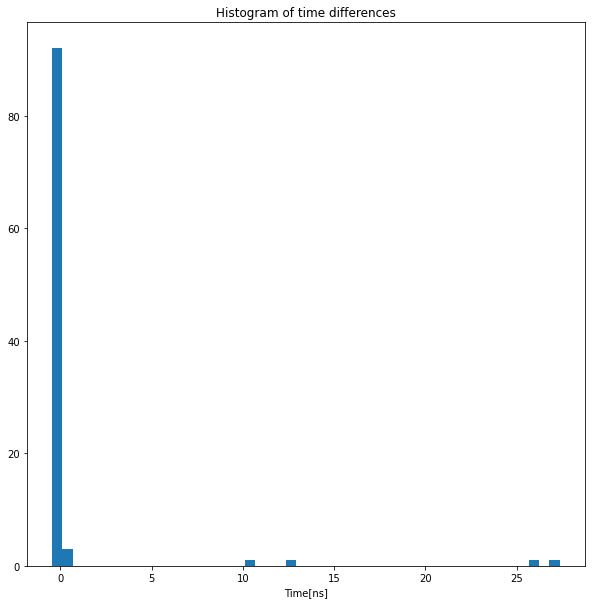

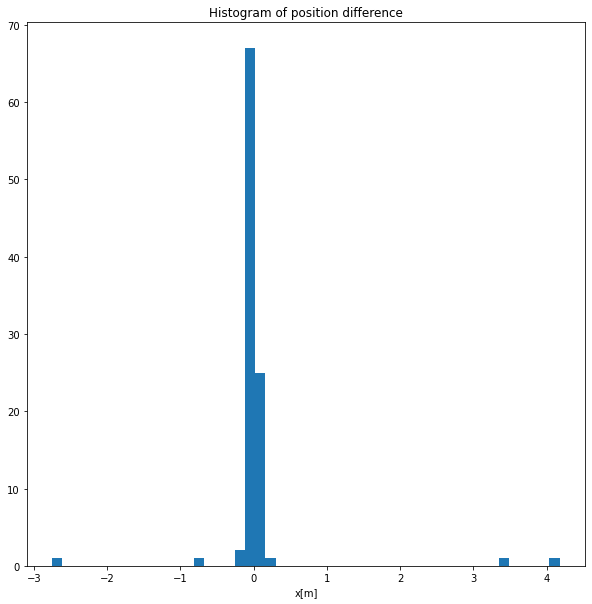

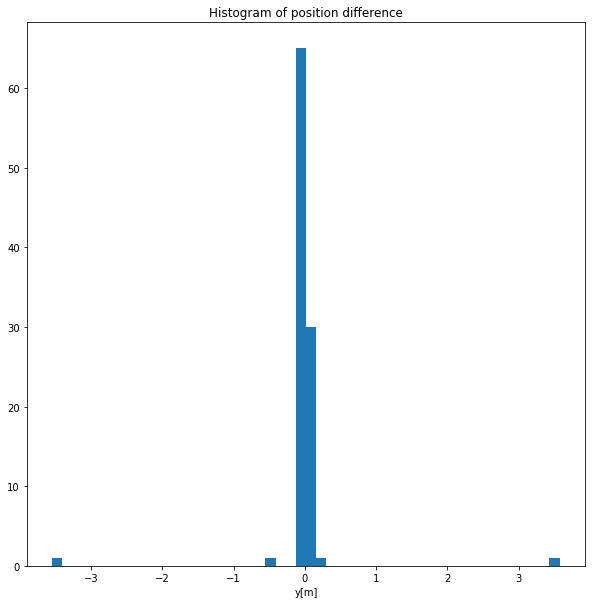

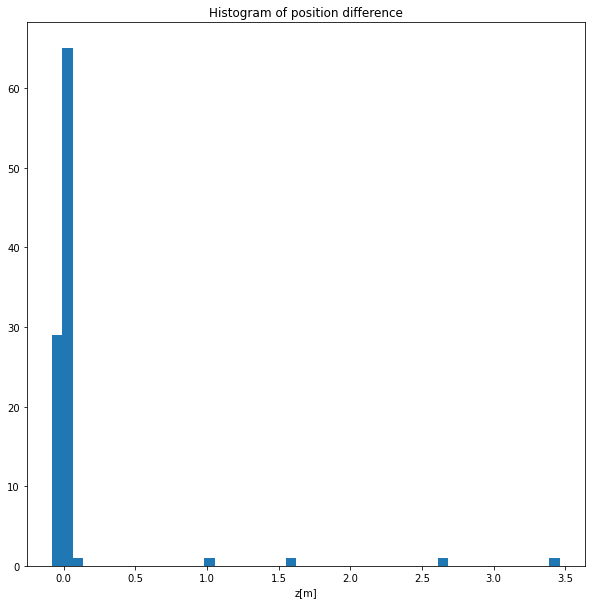

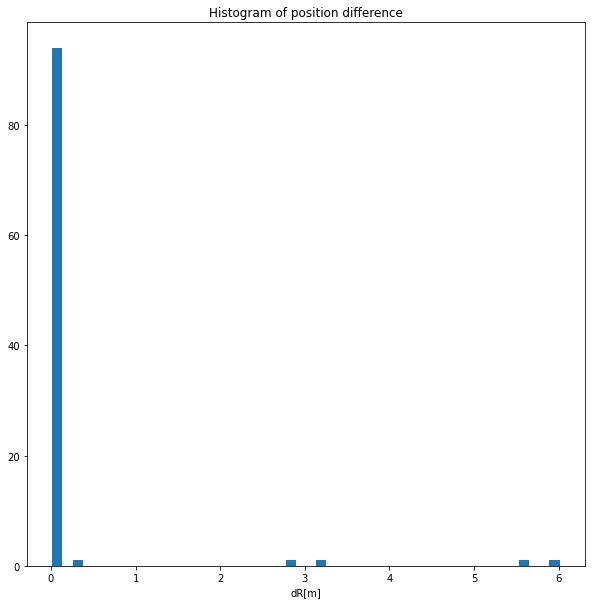

In [550]:
delt=[t0-sol[0] for pL,t0,v,sol in events]
plt.hist(delt,50)
plt.title("Histogram of time differences")
plt.xlabel("Time[ns]")
plt.show()

delx=[v[0]-sol[1] for pL,t0,v,sol in events]
plt.hist(delx,50)
plt.title("Histogram of position difference")
plt.xlabel("x[m]")
plt.show()

dely=[v[1]-sol[2] for pL,t0,v,sol in events]
plt.hist(dely,50)
plt.title("Histogram of position difference")
plt.xlabel("y[m]")
plt.show()

delz=[v[2]-sol[3] for pL,t0,v,sol in events]
plt.hist(delz,50)
plt.title("Histogram of position difference")
plt.xlabel("z[m]")
plt.show()

delr=[np.linalg.norm(v-sol[1:]) for pL,t0,v,sol in events]
plt.hist(delr,50)
plt.title("Histogram of position difference")
plt.xlabel("dR[m]")
plt.show()
